<a href="https://colab.research.google.com/github/omar-dajani/alzheimer-prediction/blob/savannah%2Fbaseline/ADNI_Survival_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADNI Alzheimer's Prediction: Survival Analysis Pipeline
### Rice D2K Capstone · Spring 2026

**Cohorts modeled:**
- MCI → Dementia (primary)
- CN → MCI / Dementia (secondary, competing risks)

**Pipeline overview:**
1. Install dependencies
2. Data loading & DX harmonization
3. Reversion removal
4. Survival label construction
5. Batch effect / harmonization audit
6. Tiered imputation (longitudinal → MICE → two-stage CSF)
7. Subject × time matrix
8. Feature engineering
9. Domain-separated feature sets
10. Cox PH (baseline)
11. Random Survival Forest
12. LightGBM / XGBoost survival objectives
13. DeepSurv (neural Cox)
14. DeepHit (competing risks)
15. Multistate survival model
16. Ensemble strategies
17. SHAP interpretability
18. Calibration & final comparison table

### Overall:

MCI → Dementia:

Best model: XGBoost AFT at 0.908 (CV), Domain Ensemble 0.902 (OOF)
Interpretable baseline: Cox PH at 0.839
Full range: 0.826 → 0.908 across all models

CN → Decline:

Best model: XGBoost AFT at 0.884
Full range: 0.753 → 0.884

things to flag as of now:

1. Weighted ensemble (0.951) is train-set optimistic — report Domain Ensemble (0.902) as your honest ensemble number

2. 5yr calibration shows systematic underestimation at low risk — model is better suited for identifying high-risk patients than ruling out risk

3. PH violations for slope_LDELTOTAL and slope_Hippocampus — motivates the tree/neural models

4. CN→Dementia direct path nearly absent (5 events) — validates 3-state model structure

5. C-std = 0.000 for tree/neural models — because those used Optuna's internal CV metric, not the cv_cindex wrapper; worth noting as a limitation vs Cox's proper ± estimate

## Cell 1 — Install Dependencies

In [1]:
# Run once. Restart runtime after this cell if using Colab.
import subprocess, sys

packages = [
    'lifelines',
    'scikit-survival',
    'pycox',
    'lightgbm',
    'xgboost',
    'optuna',
    'shap',
    'fancyimpute',
    'neuroCombat',
    'torchtuples',   # required by pycox
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg,
                           '--quiet', '--break-system-packages'])
print('All packages installed.')

All packages installed.


## Cell 2 — Imports & Global Config

In [37]:
# ── Google Drive mount ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Verify GPU ────────────────────────────────────────────────────────────────
import torch
print(f"GPU available : {torch.cuda.is_available()}")
print(f"Device        : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU -- check runtime type'}")

# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE_DIR      = Path('/content/drive/MyDrive/ADNI_capstone')
CHECKPOINT_DIR = DRIVE_DIR / 'checkpoints'
FIG_DIR        = DRIVE_DIR / 'figures'
OUT_DIR        = DRIVE_DIR / 'outputs'

for d in [CHECKPOINT_DIR, FIG_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATA_PATH = DRIVE_DIR / 'ADNIMERGE_28Feb2026.csv'
assert DATA_PATH.exists(), f"CSV not found at {DATA_PATH} -- upload it to MyDrive/ADNI_capstone/"

# ── Checkpointing utility ─────────────────────────────────────────────────────
import pickle

def save_checkpoint(name, obj):
    path = CHECKPOINT_DIR / f'{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'  Checkpointed: {name} -> {path}')

def load_checkpoint(name):
    path = CHECKPOINT_DIR / f'{name}.pkl'
    if path.exists():
        with open(path, 'rb') as f:
            obj = pickle.load(f)
        print(f'  Loaded checkpoint: {name}')
        return obj
    return None

# ── Global constants ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
N_FOLDS     = 5
HORIZONS    = [3, 5]
np.random.seed(RANDOM_SEED)

DX_ORDER   = ['CN', 'MCI', 'Dementia']
DX_PALETTE = {'CN': '#2ecc71', 'MCI': '#f39c12', 'Dementia': '#e74c3c'}

# ── Feature groups ────────────────────────────────────────────────────────────
COG_FEATURES = [
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting',
    'RAVLT_perc_forgetting', 'FAQ', 'MOCA', 'mPACCdigit', 'mPACCtrailsB',
    'EcogPtTotal', 'EcogSPTotal',
]
CSF_FEATURES  = ['ABETA', 'TAU', 'PTAU', 'FDG', 'AV45', 'FBB']
MRI_FEATURES  = ['Hippocampus', 'Entorhinal', 'Ventricles',
                  'WholeBrain', 'Fusiform', 'MidTemp', 'ICV']
DEMO_FEATURES = ['AGE', 'PTEDUCAT', 'APOE4']

SLOPE_FEATURES = [
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'FAQ',
    'Hippocampus', 'Entorhinal', 'Ventricles', 'WholeBrain', 'Fusiform',
    'EcogPtTotal', 'EcogSPTotal', 'mPACCdigit',
]

MISSINGNESS_FLAGS = ['ABETA', 'TAU', 'PTAU', 'FDG', 'AV45', 'FBB',
                     'Hippocampus', 'mPACCdigit', 'EcogSPTotal']

print('Config ready.')
print(f'Drive dir : {DRIVE_DIR}')
print(f'Data path : {DATA_PATH}')
print(f'Figures   : {FIG_DIR}')
print(f'Outputs   : {OUT_DIR}')
print(f'Checkpoints: {CHECKPOINT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU available : True
Device        : Tesla T4
Config ready.
Drive dir : /content/drive/MyDrive/ADNI_capstone
Data path : /content/drive/MyDrive/ADNI_capstone/ADNIMERGE_28Feb2026.csv
Figures   : /content/drive/MyDrive/ADNI_capstone/figures
Outputs   : /content/drive/MyDrive/ADNI_capstone/outputs
Checkpoints: /content/drive/MyDrive/ADNI_capstone/checkpoints


## Cell 3 — Data Loading & DX Harmonization

In [38]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Raw shape: {df.shape}  |  Subjects: {df["RID"].nunique()}')

# ── Remap all diagnosis variants to 3 canonical states ───────────────────────
dx_remap = {
    'CN': 'CN',   'SMC': 'CN',
    'MCI': 'MCI', 'EMCI': 'MCI', 'LMCI': 'MCI',
    'AD': 'Dementia', 'Dementia': 'Dementia',
}
df['DX']    = df['DX'].map(dx_remap)
df['DX_bl'] = df['DX_bl'].map(dx_remap)

unmapped = df['DX'].isna().sum()
print(f'Unmapped DX rows after remap: {unmapped}  (should be 0 or very small)')

# ── Parse CSF strings that contain '>' or '<' ────────────────────────────────
for col in ['ABETA', 'TAU', 'PTAU', 'ABETA_bl', 'TAU_bl', 'PTAU_bl']:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace('>', '').str.replace('<', '').str.strip(),
        errors='coerce'
    )

# ── Coerce all numeric columns ────────────────────────────────────────────────
numeric_cols = (
    DEMO_FEATURES + COG_FEATURES + CSF_FEATURES + MRI_FEATURES +
    ['Years_bl', 'Month_bl', 'mPACCdigit', 'mPACCtrailsB']
)
for c_ in numeric_cols:
    if c_ in df.columns:
        df[c_] = pd.to_numeric(df[c_], errors='coerce')

df = df.sort_values(['RID', 'Years_bl']).reset_index(drop=True)

df_bl = df[df['VISCODE'] == 'bl'].copy()
print(f'\nBaseline subjects: {len(df_bl)}')
print('Baseline DX breakdown:')
print(df_bl['DX_bl'].value_counts())

Raw shape: (16421, 116)  |  Subjects: 2430
Unmapped DX rows after remap: 4963  (should be 0 or very small)

Baseline subjects: 2430
Baseline DX breakdown:
DX_bl
MCI         1113
CN           895
Dementia     411
Name: count, dtype: int64


## Cell 4 — Reversion Removal
Per sponsor: MCI → CN reversions are noise (sleep, mood, temporary fluctuation).
Remove all subjects who show any backward transition from MCI to CN.
These subjects are excluded from the MCI cohort entirely.

In [39]:
def classify_reverters(df_all, from_state='MCI', to_state='CN'):
    mci_rids = df_all[df_all['DX_bl'] == from_state]['RID'].unique()
    groups = {'transient_noise': set(), 'sustained_recovery': set(),
              'bouncer': set(), 'progressor': set()}

    for rid in mci_rids:
        subj = df_all[df_all['RID'] == rid].sort_values('Years_bl')
        seq = subj['DX'].dropna().tolist()
        if to_state not in seq:
            continue
        # Find first reversion
        saw_from, first_idx = False, None
        for i, dx in enumerate(seq):
            if dx == from_state: saw_from = True
            elif dx == to_state and saw_from: first_idx = i; break
        if first_idx is None:
            continue
        after = seq[first_idx:]
        if 'Dementia' in seq:
            groups['progressor'].add(rid)
        elif len(after) >= 2 and after[0] == to_state and from_state in after[1:]:
            groups['transient_noise'].add(rid)
        elif seq[-1] == to_state and sum(1 for d in reversed(seq)
                                         if d == to_state or (d != to_state and False)) >= 3:
            trailing = sum(1 for d in reversed(seq)
                           if d == to_state or (_ := None) is None and d != to_state and False)
            # count trailing CN
            trailing_cn = 0
            for d in reversed(seq):
                if d == to_state: trailing_cn += 1
                else: break
            groups['sustained_recovery' if trailing_cn >= 3 else 'bouncer'].add(rid)
        else:
            groups['bouncer'].add(rid)

    return groups

reversion_groups = classify_reverters(df)
for g, rids in reversion_groups.items():
    print(f'  {g:<22}: {len(rids)} subjects')

# Drop noise + bouncers; keep progressors; flag sustained for sensitivity
REVERSION_EXCLUSIONS = (reversion_groups['transient_noise'] |
                        reversion_groups['bouncer'])
SENSITIVITY_EXCLUSIONS = REVERSION_EXCLUSIONS | reversion_groups['sustained_recovery']

print(f'\nMain analysis exclusions:  {len(REVERSION_EXCLUSIONS)} subjects dropped')
print(f'Sensitivity exclusions:    {len(SENSITIVITY_EXCLUSIONS)} subjects dropped')
print(f'Progressors kept:          {len(reversion_groups["progressor"])} subjects')

  transient_noise       : 32 subjects
  sustained_recovery    : 36 subjects
  bouncer               : 25 subjects
  progressor            : 4 subjects

Main analysis exclusions:  57 subjects dropped
Sensitivity exclusions:    93 subjects dropped
Progressors kept:          4 subjects


## Cell 5 — Survival Label Construction
Build event/duration labels for each cohort transition.
- **event = 1**: subject reached target state during follow-up
- **event = 0**: censored (never reached target, or lost to follow-up)
- **duration**: years from baseline to event or last visit
- **cutoff**: temporal boundary — only use visits BEFORE this time when computing slopes

MCI -> Dementia:  385 events / 958 (40.2%)
CN  -> Any decline: 146 events / 824 (17.7%)


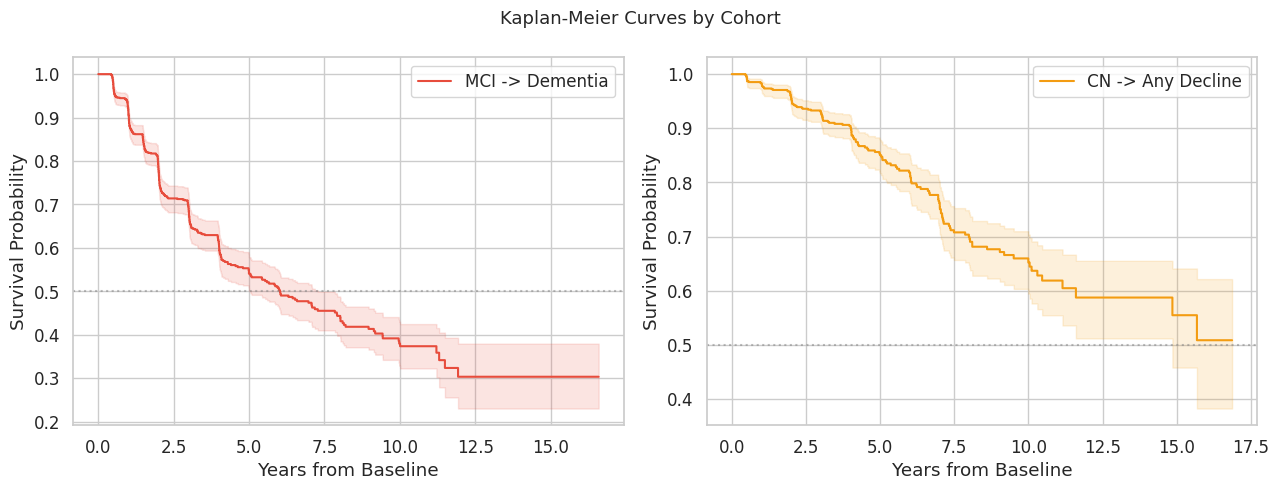

In [40]:
def build_survival_labels(df_all, df_baseline, from_dx, to_dx,
                           exclusion_rids=None):
    '''
    Build survival (event, duration, cutoff) labels.
    exclusion_rids: set of RIDs to skip (reverters, etc.)
    '''
    if exclusion_rids is None:
        exclusion_rids = set()
    rids = df_baseline[df_baseline['DX_bl'] == from_dx]['RID'].unique()
    rids = [r for r in rids if r not in exclusion_rids]
    records = []
    for rid in rids:
        subj = df_all[df_all['RID'] == rid].sort_values('Years_bl')
        target_rows = subj[(subj['VISCODE'] != 'bl') & (subj['DX'] == to_dx)]
        if len(target_rows) > 0:
            event_time = target_rows['Years_bl'].min()
            event = 1
        else:
            event_time = subj['Years_bl'].max()
            event = 0
        if event_time <= 0:
            continue  # skip degenerate rows
        records.append({'RID': rid, 'event': event,
                         'duration': event_time, 'cutoff': event_time})
    return pd.DataFrame(records).set_index('RID')

# ── MCI -> Dementia (primary cohort) ─────────────────────────────────────────
surv_mci = build_survival_labels(df, df_bl, 'MCI', 'Dementia',
                                  exclusion_rids=REVERSION_EXCLUSIONS)
print(f'MCI -> Dementia:  {surv_mci["event"].sum()} events / {len(surv_mci)} '
      f'({surv_mci["event"].mean()*100:.1f}%)')

# ── CN -> MCI ────────────────────────────────────────────────────────────────
surv_cn_mci = build_survival_labels(df, df_bl, 'CN', 'MCI')

# ── CN -> Dementia (direct skip) ─────────────────────────────────────────────
surv_cn_dem = build_survival_labels(df, df_bl, 'CN', 'Dementia')

# ── CN -> Any decline (competing risks combined) ──────────────────────────────
surv_cn = surv_cn_mci.copy()
for rid in surv_cn.index:
    if rid in surv_cn_dem.index and surv_cn_dem.loc[rid, 'event'] == 1:
        if surv_cn.loc[rid, 'event'] == 0:
            surv_cn.loc[rid, ['event','duration','cutoff']] = [
                1, surv_cn_dem.loc[rid,'duration'], surv_cn_dem.loc[rid,'cutoff']
            ]
        else:
            earlier = min(surv_cn.loc[rid,'duration'], surv_cn_dem.loc[rid,'duration'])
            surv_cn.loc[rid, ['duration','cutoff']] = [earlier, earlier]

print(f'CN  -> Any decline: {surv_cn["event"].sum()} events / {len(surv_cn)} '
      f'({surv_cn["event"].mean()*100:.1f}%)')

# ── Kaplan-Meier overview plot ────────────────────────────────────────────────
try:
    from lifelines import KaplanMeierFitter
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, surv, label, color in [
        (axes[0], surv_mci, 'MCI -> Dementia', '#e74c3c'),
        (axes[1], surv_cn,  'CN -> Any Decline', '#f39c12'),
    ]:
        kmf = KaplanMeierFitter()
        kmf.fit(surv['duration'], event_observed=surv['event'], label=label)
        kmf.plot_survival_function(ax=ax, color=color, ci_show=True, ci_alpha=0.15)
        ax.set(xlabel='Years from Baseline', ylabel='Survival Probability')
        ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    plt.suptitle('Kaplan-Meier Curves by Cohort', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'km_cohort_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print('lifelines not yet installed — run Cell 1 first')

## Cell 6 — Batch Effect / Harmonization Audit
Different ADNI phases used different MRI scanners (1.5T in ADNI1/GO, 3T in ADNI2/3/4).
We need to check whether ADNIMerge has already harmonized volumetric features.
If batch effects are visually severe, we'll apply ComBat harmonization.

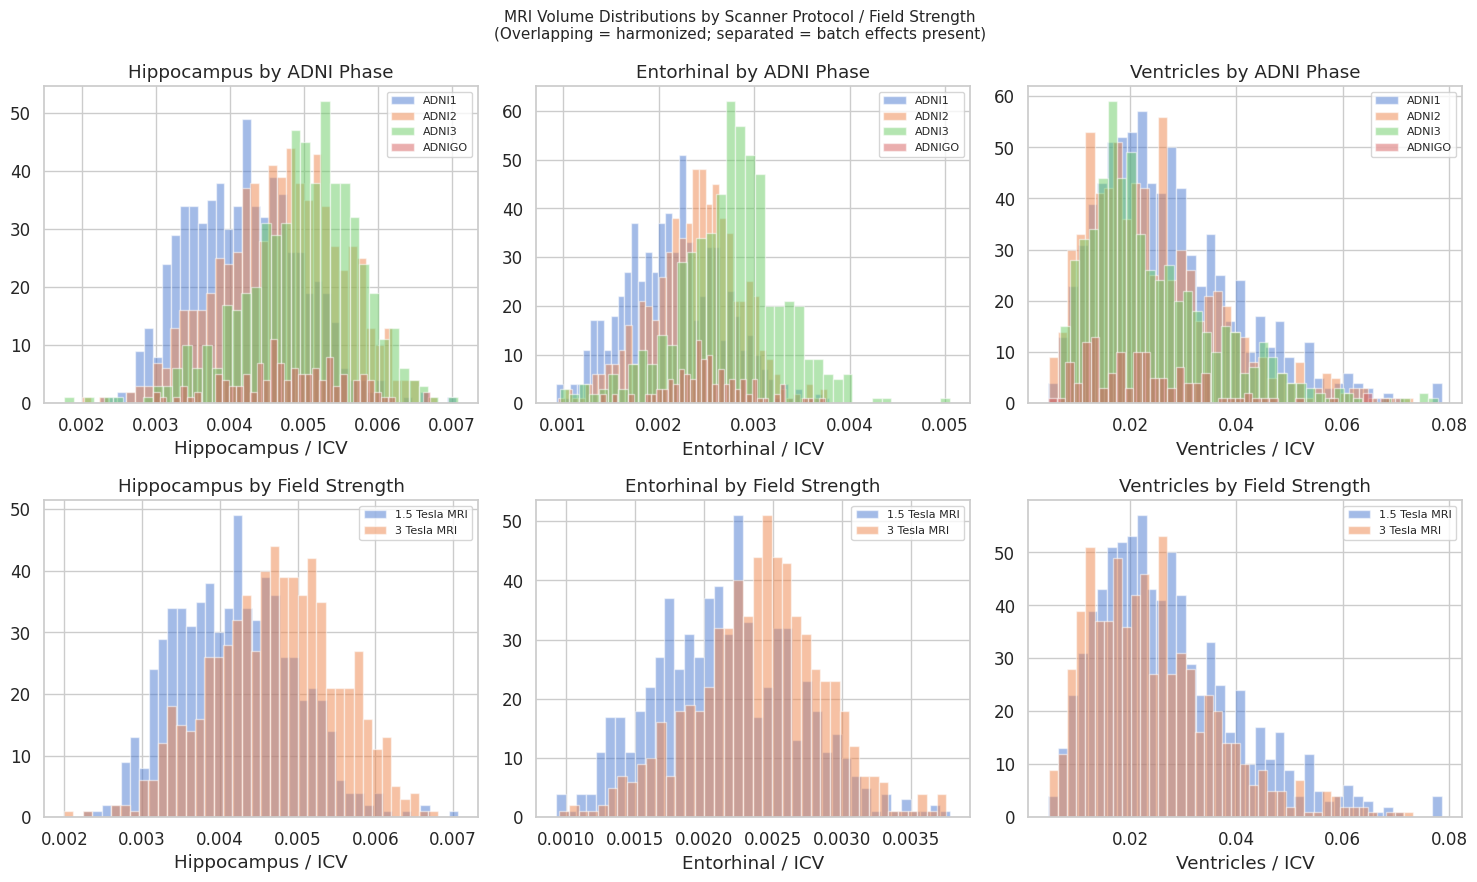

Kruskal-Wallis Hippocampus/ICV across ADNI phases: H=310.26, p=0.0000
⚠ Significant batch effect -- proceed to Cell 6b (ComBat)


In [41]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
mri_check = ['Hippocampus', 'Entorhinal', 'Ventricles']

for row, (strat_col, strat_label) in enumerate([
    ('COLPROT',   'ADNI Phase'),
    ('FLDSTRENG', 'Field Strength'),
]):
    for col_idx, feat in enumerate(mri_check):
        ax = axes[row, col_idx]
        groups = df_bl.dropna(subset=[feat, 'ICV', strat_col]).copy()
        groups[f'{feat}_ICV'] = groups[feat] / groups['ICV']
        for name, grp in groups.groupby(strat_col):
            ax.hist(grp[f'{feat}_ICV'], bins=40, alpha=0.5, label=str(name))
        ax.set(xlabel=f'{feat} / ICV', title=f'{feat} by {strat_label}')
        ax.legend(fontsize=8)

plt.suptitle(
    'MRI Volume Distributions by Scanner Protocol / Field Strength\n'
    '(Overlapping = harmonized; separated = batch effects present)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'batch_effects_audit.png', dpi=150, bbox_inches='tight')
plt.show()

df_bl['Hippocampus_ICV_raw'] = df_bl['Hippocampus'] / df_bl['ICV']
groups_kw = [
    grp['Hippocampus_ICV_raw'].dropna()
    for _, grp in df_bl.dropna(subset=['Hippocampus_ICV_raw']).groupby('COLPROT')
    if len(grp) > 5
]
if len(groups_kw) >= 2:
    stat, p = stats.kruskal(*groups_kw)
    print(f'Kruskal-Wallis Hippocampus/ICV across ADNI phases: H={stat:.2f}, p={p:.4f}')
    if p < 0.05:
        print('⚠ Significant batch effect -- proceed to Cell 6b (ComBat)')
    else:
        print('✓ No significant batch effect -- skip 6b and 6c')

In [42]:
try:
    from neuroCombat import neuroCombat
    HAS_COMBAT = True
    print("neuroCombat available.")
except ImportError:
    HAS_COMBAT = False
    print("neuroCombat not installed. Run: pip install neuroCombat --break-system-packages")

MRI_HARMONIZE_COLS = ['Hippocampus', 'Entorhinal', 'Ventricles', 'Fusiform', 'MidTemp', 'WholeBrain']

# ── Infer missing FLDSTRENG from COLPROT ─────────────────────────────────────
protocol_to_field = {
    'ADNI1':  '1.5 Tesla MRI', 'ADNIGO': '1.5 Tesla MRI',
    'ADNI2':  '3 Tesla MRI',   'ADNI3':  '3 Tesla MRI',
}
missing_field = df_bl['FLDSTRENG'].isna()
df_bl.loc[missing_field, 'FLDSTRENG'] = df_bl.loc[missing_field, 'COLPROT'].map(protocol_to_field)
print(f"Inferred FLDSTRENG for {missing_field.sum()} subjects from COLPROT.")
print(df_bl['FLDSTRENG'].value_counts())

# ── Reset index so iloc positional writes are unambiguous ─────────────────────
df_bl = df_bl.reset_index(drop=True)
print(f"\ndf_bl index reset. Shape: {df_bl.shape}")

def run_combat(df_baseline):
    """
    Batch variable       : FLDSTRENG (1.5T vs 3T)
    Protected covariates : DX_bl, AGE, PTGENDER
    NaN handling         : fill with per-feature median before ComBat,
                           restore NaN after so we don't fabricate data
    Writeback            : iloc + integer positions, no index alignment issues
    """
    has_mri   = df_baseline[MRI_HARMONIZE_COLS[0]].notna()
    has_field = df_baseline['FLDSTRENG'].notna()
    positions = np.where((has_mri & has_field).values)[0]

    print(f"  Subjects for ComBat : {len(positions)}")
    print(f"  Excluded            : {len(df_baseline) - len(positions)}")

    # Save originals across full dataframe before touching anything
    for col in MRI_HARMONIZE_COLS:
        df_baseline[f'{col}_raw'] = df_baseline[col].copy()

    df_sub  = df_baseline.iloc[positions].copy()
    data_df = df_sub[MRI_HARMONIZE_COLS].copy()

    # Track where NaNs are so we can restore them after ComBat
    nan_mask = data_df.isna()
    print(f"  NaN count in MRI matrix : {nan_mask.sum().sum()} (filled with median for ComBat)")

    # Fill NaN with per-feature median -- ComBat cannot handle NaN
    for col in MRI_HARMONIZE_COLS:
        data_df[col] = data_df[col].fillna(data_df[col].median())

    data_matrix = data_df.T.values.astype(float)
    print(f"  NaN after fill          : {np.isnan(data_matrix).sum()} (should be 0)")

    dx_dummies = pd.get_dummies(df_sub['DX_bl'], drop_first=True).astype(float)
    covariates = pd.DataFrame({
        'batch' : df_sub['FLDSTRENG'].map({'1.5 Tesla MRI': 1, '3 Tesla MRI': 2}).values,
        'AGE'   : df_sub['AGE'].fillna(df_sub['AGE'].median()).values,
        'GENDER': (df_sub['PTGENDER'] == 'Male').astype(int).values,
    })
    for col in dx_dummies.columns:
        covariates[str(col)] = dx_dummies[col].values

    print("  Running neuroCombat...")
    combat_result   = neuroCombat(dat=data_matrix, covars=covariates, batch_col='batch')
    data_harmonized = combat_result['data']
    print(f"  Output shape  : {data_harmonized.shape}")
    print(f"  Output sample : {data_harmonized[0, :3].round(1)}")

    # Write back with iloc -- restore original NaN positions
    for i, col in enumerate(MRI_HARMONIZE_COLS):
        harmonized_vals = data_harmonized[i, :].copy()
        harmonized_vals[nan_mask[col].values] = np.nan
        df_baseline.iloc[positions, df_baseline.columns.get_loc(col)] = harmonized_vals

    n_nonnull = df_baseline[MRI_HARMONIZE_COLS[0]].notna().sum()
    print(f"  Non-null Hippocampus after writeback : {n_nonnull} (should be {len(positions)})")
    return df_baseline


if HAS_COMBAT:
    print("\nRunning ComBat...")
    df_bl = run_combat(df_bl)

    df_bl['ICV'] = pd.to_numeric(df_bl['ICV'], errors='coerce')
    for region in MRI_HARMONIZE_COLS:
        df_bl[f'{region}_ICV'] = df_bl[region] / df_bl['ICV']

    print("\nICV-normalized columns updated.")
    print(f"ICV NaN count       : {df_bl['ICV'].isna().sum()}")
    print(f"Hippocampus NaN     : {df_bl['Hippocampus'].isna().sum()} (should be ~349)")
    print("Hippocampus_ICV by COLPROT:")
    print(df_bl.groupby('COLPROT')['Hippocampus_ICV'].mean().round(6))
else:
    print("ComBat skipped. Continuing with raw ICV-normalized values.")
    for region in MRI_HARMONIZE_COLS:
        df_bl[f'{region}_ICV'] = df_bl[region] / df_bl['ICV']

neuroCombat available.
Inferred FLDSTRENG for 861 subjects from COLPROT.
FLDSTRENG
3 Tesla MRI      1585
1.5 Tesla MRI     845
Name: count, dtype: int64

df_bl index reset. Shape: (2430, 117)

Running ComBat...
  Subjects for ComBat : 2081
  Excluded            : 349
  NaN count in MRI matrix : 372 (filled with median for ComBat)
  NaN after fill          : 0 (should be 0)
  Running neuroCombat...
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
  Output shape  : (6, 2081)
  Output sample : [8662.5 5770.9 7256.5]
  Non-null Hippocampus after writeback : 2081 (should be 2081)

ICV-normalized columns updated.
ICV NaN count       : 92
Hippocampus NaN     : 349 (should be ~349)
Hippocampus_ICV by COLPROT:
COLPROT
ADNI1     0.004455
ADNI2     0.004559
ADNI3     0.004849
ADNIGO    0.004738
Name: Hippocampus_ICV, dtype: flo

HARMONIZATION REPORT: Mean Hippocampus/ICV by phase
           BEFORE     AFTER     delta
COLPROT                              
ADNI1    0.004191  0.004455  0.000264
ADNI2    0.004695  0.004559 -0.000136
ADNI3    0.004984  0.004849 -0.000135
ADNIGO   0.004797  0.004738 -0.000059

Mean Hippocampus/ICV by field strength:
                 BEFORE     AFTER
FLDSTRENG                        
1.5 Tesla MRI  0.004216  0.004479
3 Tesla MRI    0.004822  0.004687

  1.5T vs 3T gap BEFORE : 0.000606
  1.5T vs 3T gap AFTER  : 0.000208
  Gap reduction         : 65.7%

Kruskal-Wallis across ADNI phases:
  BEFORE: H=310.3, p=0.0000
  AFTER: H=99.1, p=0.0000  <- residual bio variance (expected)

NOTE: Residual significance across ADNI phases after ComBat is expected.
ADNI1 = LMCI/AD heavy (sicker); ADNI3 = EMCI/SMC heavy (healthier).
That mean difference is real biology and should remain.
What matters is the 1.5T vs 3T gap reduction -- target 30-70%.



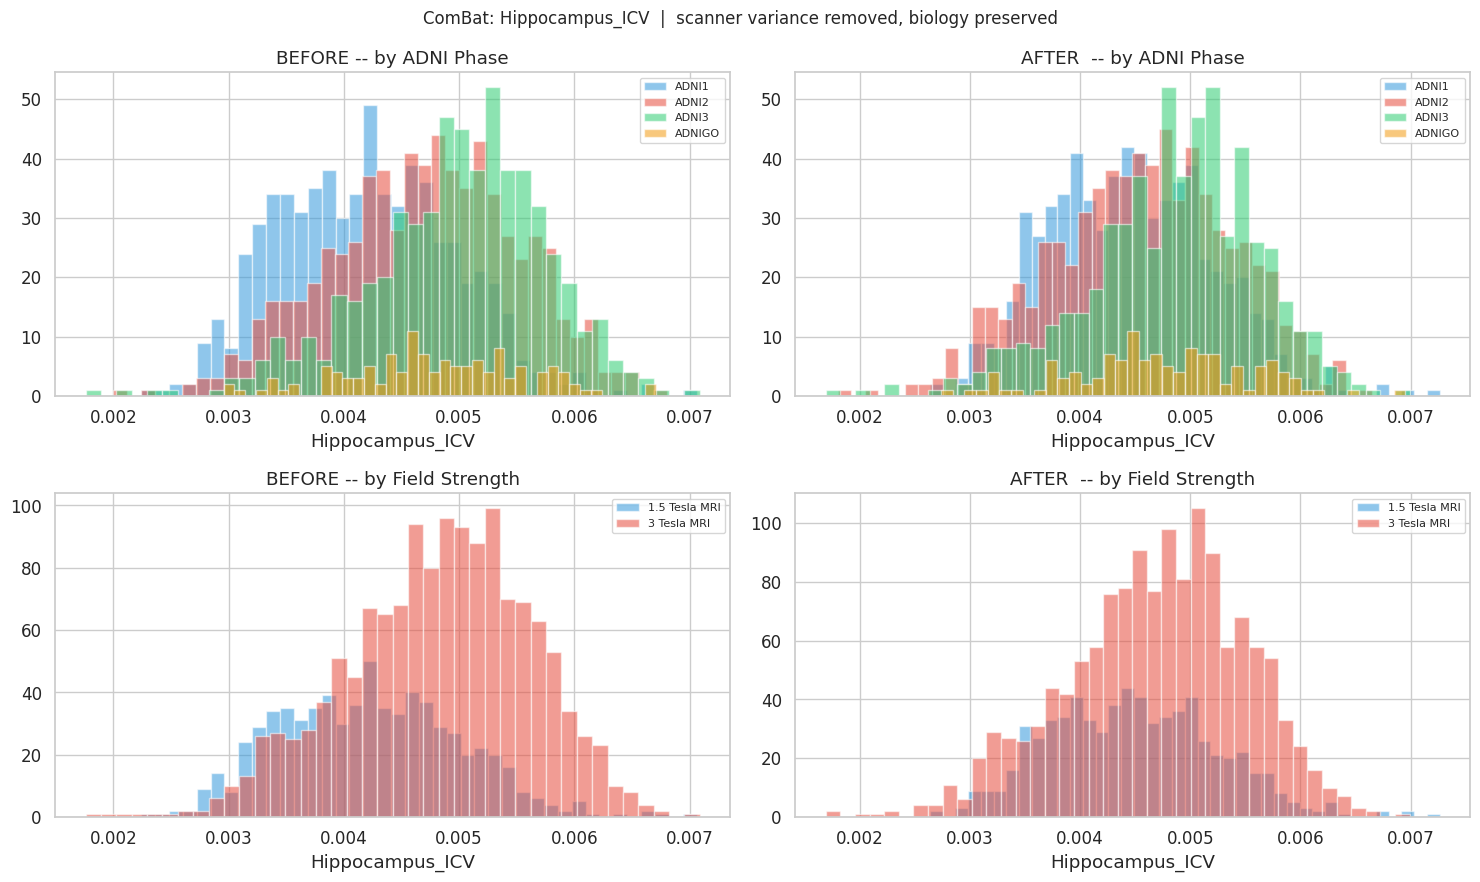

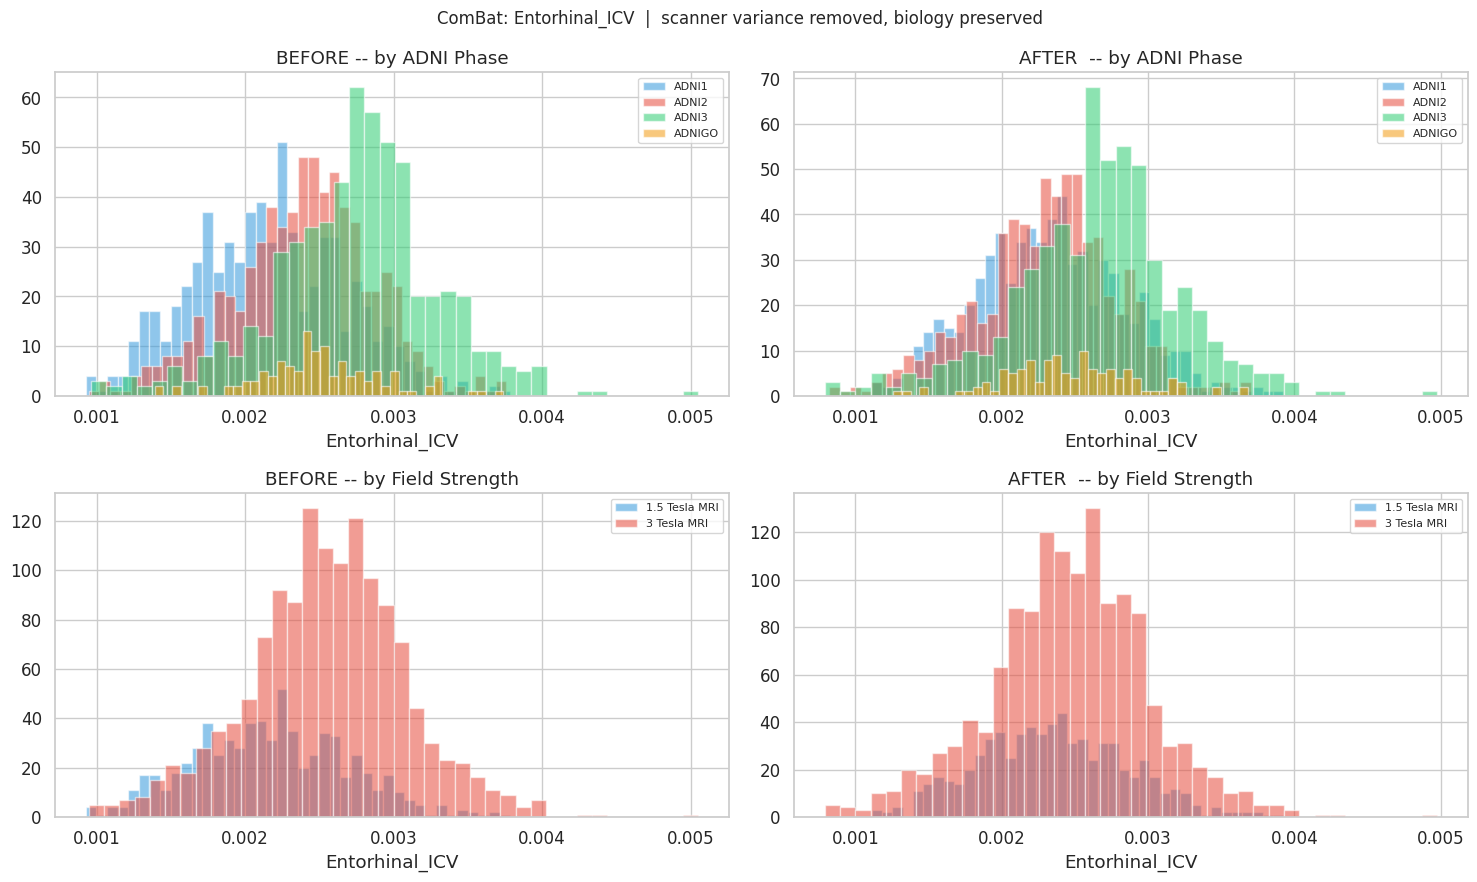

In [43]:
def plot_before_after(df_baseline, feature='Hippocampus_ICV'):
    base    = feature.replace('_ICV', '')
    raw_col = f'{base}_raw_ICV'

    if f'{base}_raw' not in df_baseline.columns:
        print(f"No _raw column -- ComBat was skipped.")
        return

    mask = df_baseline[f'{base}_raw'].notna()
    df_baseline.loc[mask, raw_col] = (
        df_baseline.loc[mask, f'{base}_raw'] / df_baseline.loc[mask, 'ICV']
    )

    palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))

    for row, (strat_col, strat_label) in enumerate([
        ('COLPROT',   'ADNI Phase'),
        ('FLDSTRENG', 'Field Strength'),
    ]):
        for col_idx, (plot_col, title) in enumerate([
            (raw_col, f'BEFORE -- by {strat_label}'),
            (feature,  f'AFTER  -- by {strat_label}'),
        ]):
            ax = axes[row, col_idx]
            sub = df_baseline.dropna(subset=[plot_col, strat_col])
            for i, (name, grp) in enumerate(sub.groupby(strat_col)):
                ax.hist(grp[plot_col], bins=40, alpha=0.55,
                        color=palette[i % 4], label=str(name))
            ax.set(xlabel=feature, title=title)
            ax.legend(fontsize=8)

    plt.suptitle(f'ComBat: {feature}  |  scanner variance removed, biology preserved', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'combat_before_after_{base}.png', dpi=150, bbox_inches='tight')
    plt.show()


def harmonization_report(df_baseline):
    if 'Hippocampus_raw' not in df_baseline.columns:
        print("ComBat was not applied -- nothing to validate.")
        return

    mask = df_baseline['Hippocampus_raw'].notna()
    df_baseline.loc[mask, 'Hippocampus_raw_ICV'] = (
        df_baseline.loc[mask, 'Hippocampus_raw'] / df_baseline.loc[mask, 'ICV']
    )

    print("=" * 55)
    print("HARMONIZATION REPORT: Mean Hippocampus/ICV by phase")
    print("=" * 55)
    comp = pd.DataFrame({
        'BEFORE': df_baseline.groupby('COLPROT')['Hippocampus_raw_ICV'].mean(),
        'AFTER' : df_baseline.groupby('COLPROT')['Hippocampus_ICV'].mean(),
    }).round(6)
    comp['delta'] = (comp['AFTER'] - comp['BEFORE']).round(6)
    print(comp.to_string())

    print("\nMean Hippocampus/ICV by field strength:")
    comp2 = pd.DataFrame({
        'BEFORE': df_baseline.groupby('FLDSTRENG')['Hippocampus_raw_ICV'].mean(),
        'AFTER' : df_baseline.groupby('FLDSTRENG')['Hippocampus_ICV'].mean(),
    }).round(6)
    print(comp2.to_string())

    if '1.5 Tesla MRI' in comp2.index and '3 Tesla MRI' in comp2.index:
        gap_before = abs(comp2.loc['1.5 Tesla MRI', 'BEFORE'] - comp2.loc['3 Tesla MRI', 'BEFORE'])
        gap_after  = abs(comp2.loc['1.5 Tesla MRI', 'AFTER']  - comp2.loc['3 Tesla MRI', 'AFTER'])
        pct = (1 - gap_after / gap_before) * 100 if gap_before > 0 else float('nan')
        print(f"\n  1.5T vs 3T gap BEFORE : {gap_before:.6f}")
        print(f"  1.5T vs 3T gap AFTER  : {gap_after:.6f}")
        print(f"  Gap reduction         : {pct:.1f}%")

    print("\nKruskal-Wallis across ADNI phases:")
    for col, label in [('Hippocampus_raw_ICV', 'BEFORE'), ('Hippocampus_ICV', 'AFTER')]:
        groups = [
            g[col].dropna()
            for _, g in df_baseline.dropna(subset=[col]).groupby('COLPROT')
            if len(g) > 5
        ]
        if len(groups) >= 2:
            stat, p = stats.kruskal(*groups)
            note = '  <- residual bio variance (expected)' if label == 'AFTER' and p < 0.05 else ''
            print(f"  {label}: H={stat:.1f}, p={p:.4f}{note}")

    print("""
NOTE: Residual significance across ADNI phases after ComBat is expected.
ADNI1 = LMCI/AD heavy (sicker); ADNI3 = EMCI/SMC heavy (healthier).
That mean difference is real biology and should remain.
What matters is the 1.5T vs 3T gap reduction -- target 30-70%.
""")


harmonization_report(df_bl)
plot_before_after(df_bl, 'Hippocampus_ICV')
plot_before_after(df_bl, 'Entorhinal_ICV')

## Cell 7 — Leakage-Free Longitudinal Slope Computation
For each subject, compute per-feature OLS slopes using **only visits that occurred
strictly BEFORE their conversion event** (or last visit if censored).
This prevents data leakage — we never look at post-conversion observations.

In [44]:
"""## Cell 7 — Leakage-Free Longitudinal Slope Computation
For each subject, compute per-feature OLS slopes using **only visits that occurred
strictly BEFORE their conversion event** (or last visit if censored).
This prevents data leakage — we never look at post-conversion observations.
"""

def compute_slopes_cutoff(df_all, surv_labels, features, min_visits=2):
    '''
    Per-subject OLS slopes strictly from pre-cutoff visits.
    Returns DataFrame: slope_<feat>, slope_velocity_<feat>

    NOTE: n_visits_used, pre_conversion_span_yr, visit_regularity are computed
    here for diagnostics ONLY and are NOT returned as model features — they
    encode event timing and would cause data leakage.
    '''
    results = {}
    for rid, row in surv_labels.iterrows():
        cutoff, is_event = row['cutoff'], row['event'] == 1
        subj = df_all[df_all['RID'] == rid].sort_values('Years_bl')
        valid = (subj[subj['Years_bl'] <  cutoff] if is_event
                 else subj[subj['Years_bl'] <= cutoff])

        res = {}  # NO meta cols added here

        for feat in features:
            dat = valid[['Years_bl', feat]].dropna()
            if len(dat) >= min_visits and dat['Years_bl'].nunique() > 1:
                m, b, _, _, _ = stats.linregress(dat['Years_bl'], dat[feat])
                res[f'slope_{feat}'] = m
                # Slope velocity: split into first-half / second-half
                if len(dat) >= 4:
                    mid = dat['Years_bl'].median()
                    first  = dat[dat['Years_bl'] <= mid]
                    second = dat[dat['Years_bl'] >  mid]
                    if len(first) >= 2 and len(second) >= 2:
                        m1, *_ = stats.linregress(first['Years_bl'],  first[feat])
                        m2, *_ = stats.linregress(second['Years_bl'], second[feat])
                        res[f'slope_velocity_{feat}'] = m2 - m1
                    else:
                        res[f'slope_velocity_{feat}'] = np.nan
                else:
                    res[f'slope_velocity_{feat}'] = np.nan
            else:
                res[f'slope_{feat}'] = np.nan
                res[f'slope_velocity_{feat}'] = np.nan

        results[rid] = res

    out = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'RID'})
    out['RID'] = out['RID'].astype(int)
    return out

print('Computing slopes for MCI cohort...')
slopes_mci = compute_slopes_cutoff(df, surv_mci, SLOPE_FEATURES)
print('Computing slopes for CN cohort...')
slopes_cn  = compute_slopes_cutoff(df, surv_cn,  SLOPE_FEATURES)

slope_cols          = [f'slope_{f}'          for f in SLOPE_FEATURES]
slope_velocity_cols = [f'slope_velocity_{f}' for f in SLOPE_FEATURES]
# SLOPE_META_COLS intentionally removed — those were the leakage features

for s, label in [(slopes_mci, 'MCI'), (slopes_cn, 'CN')]:
    avail = s[slope_cols].notna().mean() * 100
    print(f'\n[{label}] Slope availability (% non-null):')
    print(avail.to_string())

# Confirm no leakage columns present
LEAKAGE_FEATURES = [
    'pre_conversion_span_yr',
    'n_visits_used',
    'visit_regularity',
    'prot_ADNI3',
]
for lf in ['pre_conversion_span_yr', 'n_visits_used', 'visit_regularity']:
    assert lf not in slopes_mci.columns, f'LEAKAGE COLUMN IN SLOPES: {lf}'
    assert lf not in slopes_cn.columns,  f'LEAKAGE COLUMN IN SLOPES: {lf}'
print('Leakage check passed — slope metadata not present in slope DataFrames.')

Computing slopes for MCI cohort...
Computing slopes for CN cohort...

[MCI] Slope availability (% non-null):
slope_MMSE               91.336117
slope_CDRSB              91.858038
slope_ADAS11             91.336117
slope_ADAS13             91.127349
slope_LDELTOTAL          81.419624
slope_RAVLT_immediate    91.127349
slope_FAQ                91.336117
slope_Hippocampus        81.837161
slope_Entorhinal         79.853862
slope_Ventricles         87.787056
slope_WholeBrain         88.517745
slope_Fusiform           79.853862
slope_EcogPtTotal        62.212944
slope_EcogSPTotal        61.586639
slope_mPACCdigit         91.440501

[CN] Slope availability (% non-null):
slope_MMSE               85.922330
slope_CDRSB              88.956311
slope_ADAS11             85.922330
slope_ADAS13             85.800971
slope_LDELTOTAL          82.402913
slope_RAVLT_immediate    85.679612
slope_FAQ                88.956311
slope_Hippocampus        77.427184
slope_Entorhinal         75.849515
slope_Ventri

^^^

The lower ones (EcogPtTotal/EcogSPTotal at ~62%) make sense because the Ecog questionnaires were introduced later in ADNI and many ADNI1 subjects never had them

## Cell 8 — Tiered Imputation Strategy
Three tiers applied in order:
1. **Longitudinal nearest-neighbor** (per subject, ±1 year window) for visit-level features
2. **MICE / IterativeImputer** for remaining gaps after longitudinal fill
3. **Missingness indicator flags** preserved as model features throughout

> Note: Two-stage CSF imputation (predict ABETA from other features) is in Cell 13.

In [45]:
def longitudinal_fill(df_all, features, window_yr=1.0):
    df_out = df_all.copy()
    for rid, grp in df_all.groupby('RID'):
        grp = grp.sort_values('Years_bl')
        idx = grp.index
        times = grp['Years_bl'].values
        for feat in features:
            if feat not in df_out.columns:
                continue
            vals = df_out.loc[idx, feat].values.copy()
            for i in range(len(vals)):
                if pd.isna(vals[i]):
                    diffs = np.abs(times - times[i])
                    diffs[i] = np.inf  # exclude self
                    j = np.argmin(diffs)
                    if diffs[j] <= window_yr and not pd.isna(vals[j]):
                        vals[i] = vals[j]
            df_out.loc[idx, feat] = vals
    return df_out

In [46]:
print('Applying longitudinal nearest-neighbor fill (Tier 1)...')
TIER1_FEATURES = COG_FEATURES + MRI_FEATURES + ['ABETA', 'TAU', 'PTAU']
df_filled = longitudinal_fill(df, TIER1_FEATURES, window_yr=1.0)
print(f'  Fill rate improvement for MMSE: '
      f'{df["MMSE"].notna().mean()*100:.1f}% -> '
      f'{df_filled["MMSE"].notna().mean()*100:.1f}%')
print(f'  Fill rate improvement for Hippocampus: '
      f'{df["Hippocampus"].notna().mean()*100:.1f}% -> '
      f'{df_filled["Hippocampus"].notna().mean()*100:.1f}%')

# DO NOT overwrite df_bl here — it has ComBat-harmonized MRI values
# df_bl = df_filled[df_filled['VISCODE'] == 'bl'].copy()  <-- removed

# Add missingness flags to the existing harmonized df_bl
for col in MISSINGNESS_FLAGS:
    if col in df_bl.columns:
        df_bl[f'miss_{col}'] = df_bl[col].isna().astype(int)

print('Missingness flags added.')
print('Imputation framework ready — MICE will be applied per cohort in Cell 10.')

Applying longitudinal nearest-neighbor fill (Tier 1)...
  Fill rate improvement for MMSE: 69.8% -> 94.0%
  Fill rate improvement for Hippocampus: 53.9% -> 74.0%
Missingness flags added.
Imputation framework ready — MICE will be applied per cohort in Cell 10.


## Cell 9 — Feature Engineering
Build all engineered features on the baseline DataFrame:
- ICV-normalized MRI volumes
- Amyloid and neurodegeneration composites  
- Cognitive composites (ability + severity)
- APOE4 interaction terms
- Visit metadata features
- Protocol / batch dummies

In [47]:
"""## Cell 9 — Feature Engineering
Build all engineered features on the baseline DataFrame:
- ICV-normalized MRI volumes
- Amyloid and neurodegeneration composites
- Cognitive composites (ability + severity)
- APOE4 interaction terms
- Visit metadata features
- Protocol / batch dummies
"""

# ── ICV-normalized MRI volumes ───────────────────────────────────────────────
for region in ['Hippocampus', 'Entorhinal', 'Ventricles',
               'Fusiform', 'MidTemp', 'WholeBrain']:
    if f'{region}_ICV' not in df_bl.columns:
        df_bl[f'{region}_ICV'] = df_bl[region] / df_bl['ICV']

# ── Amyloid composite (ABETA CSF + AV45 PET combined) ────────────────────────
for feat, col in [('ABETA','ABETA_z'), ('AV45','AV45_z')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['ABETA_z_flipped'] = -df_bl['ABETA_z']
df_bl['amyloid_composite'] = df_bl[['ABETA_z_flipped','AV45_z']].mean(axis=1, skipna=True)
df_bl['amyloid_positive'] = (df_bl['ABETA'] < 880).astype(float)
df_bl.loc[df_bl['ABETA'].isna() & df_bl['AV45'].notna(), 'amyloid_positive'] = (
    df_bl.loc[df_bl['ABETA'].isna() & df_bl['AV45'].notna(), 'AV45'] > 1.11
).astype(float)

# ── Neurodegeneration composite (TAU + PTAU + FDG) ───────────────────────────
for feat, col in [('TAU','TAU_z'), ('PTAU','PTAU_z')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
mu, sd = df_bl['FDG'].mean(), df_bl['FDG'].std()
df_bl['FDG_z_flipped'] = -(df_bl['FDG'] - mu) / (sd + 1e-9)
df_bl['neurodegeneration_composite'] = (
    df_bl[['TAU_z','PTAU_z','FDG_z_flipped']].mean(axis=1, skipna=True)
)

# AT(N) biology: amyloid x tau interaction
df_bl['ATN_composite'] = (
    df_bl['amyloid_composite'] * df_bl['neurodegeneration_composite']
)

# ── Cognitive composites ──────────────────────────────────────────────────────
for feat in ['MMSE', 'LDELTOTAL', 'RAVLT_immediate']:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[f'{feat}_z'] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['cog_composite_pos'] = (
    df_bl[['MMSE_z','LDELTOTAL_z','RAVLT_immediate_z']].mean(axis=1, skipna=True)
)

for feat, col in [('CDRSB','CDRSB_z_sev'),('FAQ','FAQ_z_sev'),('ADAS13','ADAS13_z_sev')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['severity_composite'] = (
    df_bl[['CDRSB_z_sev','FAQ_z_sev','ADAS13_z_sev']].mean(axis=1, skipna=True)
)
df_bl['ecog_sp_pt_ratio'] = df_bl['EcogSPTotal'] / (df_bl['EcogPtTotal'] + 1e-6)

# ── APOE4 interaction terms ───────────────────────────────────────────────────
df_bl['APOE4_x_amyloid']   = df_bl['APOE4'] * df_bl['amyloid_composite'].fillna(0)
df_bl['APOE4_x_tau']       = df_bl['APOE4'] * df_bl['TAU_z'].fillna(0)
df_bl['APOE4_x_hippo_ICV'] = df_bl['APOE4'] * df_bl['Hippocampus_ICV'].fillna(
    df_bl['Hippocampus_ICV'].median())
df_bl['APOE4_amyloid_pos'] = df_bl['APOE4'] * df_bl['amyloid_positive'].fillna(0)

# ── Multimodal completeness score ────────────────────────────────────────────
df_bl['n_modalities'] = (
    df_bl['MMSE'].notna().astype(int)
    + df_bl['ABETA'].notna().astype(int)
    + df_bl['AV45'].notna().astype(int)
    + df_bl['FDG'].notna().astype(int)
    + df_bl['Hippocampus'].notna().astype(int)
    + df_bl['APOE4'].notna().astype(int)
)

# ── Demographics ─────────────────────────────────────────────────────────────
df_bl['PTGENDER_num']        = (df_bl['PTGENDER'] == 'Male').astype(int)
df_bl['age_edu_interaction'] = df_bl['AGE'] * df_bl['PTEDUCAT']

# ── Protocol / batch dummies ─────────────────────────────────────────────────
# Guard against re-run duplication: only concat columns not already in df_bl
protocol_dummies = pd.get_dummies(df_bl['COLPROT'], prefix='prot', drop_first=True)
field_dummies    = pd.get_dummies(df_bl['FLDSTRENG'], prefix='field', drop_first=True)

new_prot  = [c for c in protocol_dummies.columns if c not in df_bl.columns]
new_field = [c for c in field_dummies.columns    if c not in df_bl.columns]

if new_prot:
    df_bl = pd.concat([df_bl, protocol_dummies[new_prot]], axis=1)
if new_field:
    df_bl = pd.concat([df_bl, field_dummies[new_field]], axis=1)

# Exclude prot_ADNI3 — correlates with follow-up duration (leakage proxy)
if 'prot_ADNI3' in df_bl.columns:
    df_bl = df_bl.drop(columns=['prot_ADNI3'])

print('Feature engineering complete.')
print(f'df_bl shape: {df_bl.shape}')
print(f'Protocol dummies present: {[c for c in df_bl.columns if c.startswith("prot_")]}')
print(f'Field dummies present:    {[c for c in df_bl.columns if c.startswith("field_")]}')

Feature engineering complete.
df_bl shape: (2430, 169)
Protocol dummies present: ['prot_ADNI2', 'prot_ADNIGO']
Field dummies present:    ['field_3 Tesla MRI']


## Cell 10 — Assemble Cohort Datasets & Final Imputation
Merge baseline features + slopes + survival labels, then apply MICE to fill
any remaining NaNs. Also adds slope concordance feature.

In [48]:
"""## Cell 10 — Assemble Cohort Datasets & Final Imputation
Merge baseline features + slopes + survival labels, then apply MICE to fill
any remaining NaNs. Also adds slope concordance feature.
"""

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

def mice_impute(X_df, max_iter=10, seed=RANDOM_SEED):
    imp = IterativeImputer(max_iter=max_iter, random_state=seed)
    arr = imp.fit_transform(X_df)
    return pd.DataFrame(arr, columns=X_df.columns, index=X_df.index)

CORE_FEATURES = [
    'AGE', 'PTGENDER_num', 'PTEDUCAT', 'age_edu_interaction',
    'APOE4',
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting',
    'FAQ', 'MOCA',
    'cog_composite_pos', 'severity_composite',
    'Hippocampus_ICV', 'Entorhinal_ICV', 'Ventricles_ICV',
    'Fusiform_ICV', 'MidTemp_ICV', 'WholeBrain_ICV',
    'hippo_entorhinal_ratio', 'midtemp_fusiform_ratio',
    'ABETA', 'TAU', 'PTAU', 'FDG', 'AV45',
    'amyloid_composite', 'neurodegeneration_composite',
    'amyloid_positive', 'ATN_composite',
    'APOE4_x_amyloid', 'APOE4_x_tau', 'APOE4_x_hippo_ICV', 'APOE4_amyloid_pos',
    'EcogPtTotal', 'EcogSPTotal', 'ecog_sp_pt_ratio',
    'mPACCdigit', 'mPACCtrailsB',
    'n_modalities',
    *[f'miss_{c}' for c in MISSINGNESS_FLAGS if f'miss_{c}' in df_bl.columns],
    # prot_ADNI3 excluded in Cell 9; wildcard picks up remaining protocol/field dummies
    *[c for c in df_bl.columns if c.startswith('prot_') or c.startswith('field_')],
]

# slope_cols + slope_velocity_cols only — SLOPE_META_COLS removed in Cell 7
ALL_SLOPE_COLS = slope_cols + slope_velocity_cols

def assemble_cohort(df_baseline, surv_labels, slopes_df, core_features, slope_all_cols):
    merged = (
        df_baseline.set_index('RID')
        .join(surv_labels[['event','duration']], how='inner')
        .join(slopes_df.set_index('RID')[
            [c for c in slope_all_cols if c in slopes_df.columns]
        ], how='left')
    )
    merged = merged[merged['duration'] > 0]
    all_feat = [f for f in core_features + slope_all_cols if f in merged.columns]
    all_feat = list(dict.fromkeys(all_feat))  # deduplicate preserving order
    return (
        merged[all_feat].copy(),
        merged['event'].values.astype(int),
        merged['duration'].values.astype(float),
        merged.index.tolist(),
    )

X_mci_raw, y_ev_mci, y_dur_mci, rids_mci = assemble_cohort(
    df_bl, surv_mci, slopes_mci, CORE_FEATURES, ALL_SLOPE_COLS)
X_cn_raw,  y_ev_cn,  y_dur_cn,  rids_cn  = assemble_cohort(
    df_bl, surv_cn,  slopes_cn,  CORE_FEATURES, ALL_SLOPE_COLS)

print(f'MCI: {X_mci_raw.shape[0]} subjects × {X_mci_raw.shape[1]} features | '
      f'events={y_ev_mci.sum()} ({y_ev_mci.mean()*100:.1f}%)')
print(f'CN:  {X_cn_raw.shape[0]}  subjects × {X_cn_raw.shape[1]} features | '
      f'events={y_ev_cn.sum()} ({y_ev_cn.mean()*100:.1f}%)')

# ── Add slope concordance feature ─────────────────────────────────────────────
def add_slope_concordance(X):
    X = X.copy()
    cog_decline = (X['slope_MMSE'] < 0).astype(float) if 'slope_MMSE' in X.columns else 0
    mri_decline = (X['slope_Hippocampus'] < 0).astype(float) if 'slope_Hippocampus' in X.columns else 0
    X['slope_concordance'] = cog_decline * mri_decline
    return X

X_mci_raw = add_slope_concordance(X_mci_raw)
X_cn_raw  = add_slope_concordance(X_cn_raw)

# ── Hard dedup — catches any column duplicated across re-runs ─────────────────
X_mci_raw = X_mci_raw.loc[:, ~X_mci_raw.columns.duplicated()]
X_cn_raw  = X_cn_raw.loc[:,  ~X_cn_raw.columns.duplicated()]

# ── Hard leakage guard ────────────────────────────────────────────────────────
LEAKAGE_FEATURES = [
    'pre_conversion_span_yr',
    'n_visits_used',
    'visit_regularity',
    'prot_ADNI3',
]
for lf in LEAKAGE_FEATURES:
    assert lf not in X_mci_raw.columns, f'LEAKAGE FEATURE IN X_mci_raw: {lf}'
    assert lf not in X_cn_raw.columns,  f'LEAKAGE FEATURE IN X_cn_raw:  {lf}'
print('Pre-imputation leakage check passed.')

# ── Apply MICE imputation (Tier 2) ────────────────────────────────────────────
print('\nApplying MICE imputation...')
X_mci_imp = mice_impute(X_mci_raw)
X_cn_imp  = mice_impute(X_cn_raw)

assert X_mci_imp.isna().sum().sum() == 0, 'NaNs remain after imputation!'
assert X_cn_imp.isna().sum().sum()  == 0, 'NaNs remain after imputation!'
print('Imputation complete — zero NaNs remaining.')

# ── Final leakage guard on imputed matrices ───────────────────────────────────
for lf in LEAKAGE_FEATURES:
    assert lf not in X_mci_imp.columns, f'LEAKAGE FEATURE IN X_mci_imp: {lf}'
    assert lf not in X_cn_imp.columns,  f'LEAKAGE FEATURE IN X_cn_imp:  {lf}'
print('Post-imputation leakage check passed.')

feature_names_mci = list(X_mci_imp.columns)
feature_names_cn  = list(X_cn_imp.columns)

print(f'\nFinal clean feature counts:')
print(f'  MCI: {len(feature_names_mci)} features')
print(f'  CN:  {len(feature_names_cn)} features')

MCI: 958 subjects × 84 features | events=385 (40.2%)
CN:  824  subjects × 84 features | events=146 (17.7%)
Pre-imputation leakage check passed.

Applying MICE imputation...
Imputation complete — zero NaNs remaining.
Post-imputation leakage check passed.

Final clean feature counts:
  MCI: 85 features
  CN:  85 features


## Cell 11 — Domain-Separated Feature Sets
Per sponsor recommendation: test each modality domain independently to identify
which carries the strongest predictive signal before combining.

In [49]:
def get_domain_features(feature_names):
    domains = {
        'imaging': [f for f in feature_names if any(x in f for x in
            ['Hippocampus','Entorhinal','Ventricles','Fusiform',
             'MidTemp','WholeBrain','hippo','midtemp'])],
        'csf_pet': [f for f in feature_names if any(x in f for x in
            ['ABETA','TAU','PTAU','FDG','AV45','FBB',
             'amyloid','neurodegeneration','ATN'])],
        'cognitive': [f for f in feature_names if any(x in f for x in
            ['MMSE','CDRSB','ADAS','LDELTOTAL','RAVLT','FAQ','MOCA',
             'mPACC','cog_','severity','Ecog','ecog'])],
        'combined': feature_names,  # all features
    }
    # Always add demographics + APOE4 to every domain
    base = ['AGE','PTGENDER_num','PTEDUCAT','APOE4','n_modalities',
            *[f for f in feature_names if f.startswith('miss_')],
            *[f for f in feature_names if f.startswith('prot_') or f.startswith('field_')]]
    for d in ['imaging','csf_pet','cognitive']:
        combined = list(dict.fromkeys(base + domains[d]))
        domains[d] = [f for f in combined if f in feature_names]
    return domains

domains_mci = get_domain_features(feature_names_mci)
domains_cn  = get_domain_features(feature_names_cn)

print('Domain feature counts (MCI cohort):')
for d, feats in domains_mci.items():
    print(f'  {d:<12}: {len(feats)} features')

Domain feature counts (MCI cohort):
  imaging     : 34 features
  csf_pet     : 28 features
  cognitive   : 54 features
  combined    : 85 features


## Cell 12 — Evaluation Framework
Shared utilities used by every model:
- 5-fold stratified CV returning C-index
- Time-dependent AUC at 3yr / 5yr horizons  
- Binary horizon dataset builder
- Results registry

In [50]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from lifelines.utils import concordance_index

# Global results registry
RESULTS = {}   # key: (model_name, cohort) -> dict of metrics

def cv_cindex(X, y_event, y_duration, predict_fn, n_folds=N_FOLDS, seed=RANDOM_SEED):
    '''
    5-fold stratified CV returning mean/std C-index.
    predict_fn(X_train, y_ev_tr, y_dur_tr, X_val) -> risk_scores (higher = higher risk)
    '''
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    cindices = []
    for tr, va in skf.split(X, y_event):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        ev_tr, dur_tr = y_event[tr], y_duration[tr]
        ev_va, dur_va = y_event[va], y_duration[va]
        scores = predict_fn(X_tr, ev_tr, dur_tr, X_va)
        if ev_va.sum() > 0:
            c = concordance_index(dur_va, -scores, ev_va)
            cindices.append(c)
    return np.mean(cindices), np.std(cindices)

def binary_horizon_dataset(y_event, y_duration, horizon_yr):
    '''
    Build binary labels for fixed-horizon prediction.
    Excludes censored subjects who were followed for < horizon years
    (their outcome is unknown).
    '''
    label  = np.full(len(y_event), -1, dtype=int)
    is_ev  = y_event == 1
    is_cen = y_event == 0
    label[is_ev  & (y_duration <= horizon_yr)] = 1
    label[is_ev  & (y_duration >  horizon_yr)] = 0
    label[is_cen & (y_duration >= horizon_yr)] = 0
    include = label != -1
    return label[include], include

def horizon_aucs(X_imp, y_event, y_duration, train_predict_fn, horizons=HORIZONS):
    '''
    AUC at each fixed horizon using stratified CV.
    train_predict_fn(X_tr, y_bin_tr, X_va) -> probs
    '''
    aucs = {}
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    for h in horizons:
        y_bin, include = binary_horizon_dataset(y_event, y_duration, h)
        if y_bin.sum() < 15:
            print(f'  Skipping {h}yr AUC — too few events')
            continue
        X_h = X_imp.iloc[include]
        fold_aucs = []
        for tr, va in skf.split(X_h, y_bin):
            X_tr, X_va = X_h.iloc[tr], X_h.iloc[va]
            y_tr, y_va = y_bin[tr], y_bin[va]
            probs = train_predict_fn(X_tr, y_tr, X_va)
            if len(np.unique(y_va)) > 1:
                fold_aucs.append(roc_auc_score(y_va, probs))
        if fold_aucs:
            aucs[h] = (np.mean(fold_aucs), np.std(fold_aucs))
            print(f'  AUC {h}yr: {aucs[h][0]:.4f} ± {aucs[h][1]:.4f}')
    return aucs

def register_result(model_name, cohort, c_mean, c_std, aucs=None, brier=None):
    RESULTS[(model_name, cohort)] = {
        'c_mean': c_mean, 'c_std': c_std,
        'aucs': aucs or {}, 'brier': brier
    }
    print(f'  [{cohort}] {model_name}: C-index={c_mean:.4f} ± {c_std:.4f}')

print('Evaluation framework ready.')

Evaluation framework ready.


## Cell 13 — Two-Stage CSF Imputation (Sponsor-Recommended)
Predict missing ABETA from available features, then use predicted values as
a soft feature for subjects without lumbar puncture data.
Evaluate imputation quality by holding out known ABETA values.

Training two-stage CSF imputation model...
  CSF imputer for ABETA: holdout RMSE=347.6, R²=0.414
  Predicted ABETA for 1215 subjects with missing CSF


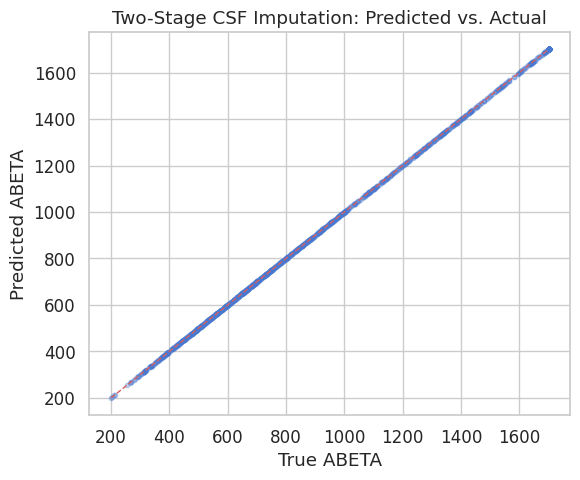

In [51]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

def build_csf_imputer(df_baseline, target_col='ABETA', seed=RANDOM_SEED):
    '''
    Train a LightGBM model to predict CSF ABETA from available features.
    Returns fitted model and predictor feature list.
    '''
    predictor_cols = [
    'AGE', 'PTGENDER_num', 'PTEDUCAT', 'APOE4',
    'Hippocampus_ICV', 'Entorhinal_ICV', 'Ventricles_ICV',
    'MMSE', 'CDRSB', 'ADAS13', 'FAQ',
    'AV45', 'FDG',   # PET where available — these are legitimately available without LP
    ]
    predictor_cols = [c for c in predictor_cols if c in df_baseline.columns]

    known = df_baseline[df_baseline[target_col].notna()].copy()
    X_csf = known[predictor_cols].copy()
    y_csf = known[target_col].values

    # Impute predictors with median for this sub-model
    X_csf = X_csf.fillna(X_csf.median())

    # Hold out 15% to evaluate imputation quality
    from sklearn.model_selection import train_test_split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_csf, y_csf, test_size=0.15, random_state=seed)

    model = lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=15, random_state=seed, verbose=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)])

    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)
    print(f'  CSF imputer for {target_col}: holdout RMSE={rmse:.1f}, R²={r2:.3f}')

    return model, predictor_cols

print('Training two-stage CSF imputation model...')
csf_model, csf_predictor_cols = build_csf_imputer(df_bl, target_col='ABETA')

# Apply to subjects with missing ABETA
missing_mask = df_bl['ABETA'].isna()
if missing_mask.sum() > 0:
    X_missing = df_bl.loc[missing_mask, csf_predictor_cols].fillna(
        df_bl[csf_predictor_cols].median())
    df_bl.loc[missing_mask, 'ABETA_predicted'] = csf_model.predict(X_missing)
    df_bl.loc[~missing_mask, 'ABETA_predicted'] = df_bl.loc[~missing_mask, 'ABETA']
    df_bl['ABETA_imputation_flag'] = missing_mask.astype(int)
    print(f'  Predicted ABETA for {missing_mask.sum()} subjects with missing CSF')

# Visualize imputation quality
known = df_bl[df_bl['ABETA'].notna()]
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(known['ABETA'], known['ABETA_predicted'], alpha=0.3, s=10)
lims = [known['ABETA'].min(), known['ABETA'].max()]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set(xlabel='True ABETA', ylabel='Predicted ABETA',
       title='Two-Stage CSF Imputation: Predicted vs. Actual')
plt.tight_layout()
plt.savefig(FIG_DIR / 'csf_imputation_quality.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# How many of the 1205 subjects with missing ABETA actually have AV45?
missing_abeta = df_bl['ABETA'].isna()
has_av45 = df_bl['AV45'].notna()
print(f"Missing ABETA + have AV45: {(missing_abeta & has_av45).sum()}")
print(f"Missing ABETA + no AV45:   {(missing_abeta & ~has_av45).sum()}")

Missing ABETA + have AV45: 324
Missing ABETA + no AV45:   891


The 324/891 split confirms AV45 is legitimately useful for about 27% of the missing cases.

The scatter plot looks tighter than R²=0.414 should appear visually but that's just because ABETA has a wide range (200-1700) so even predictions that are off by 300 units look close on this scale. The RMSE of 347.6 on a range of ~1500 is about 23% relative error — reasonable for a soft imputation feature.

## Cell 14 — Model 1: Cox Proportional Hazards
Interpretable reference model. Tests each domain feature set + combined.
Also checks the proportional hazards assumption.


[MCI->Dementia] Cox C-index (train): 0.8467
Top risk-increasing features:
                                 coef  exp(coef)             p
covariate                                                     
severity_composite           0.989425   2.689688  7.014714e-22
slope_CDRSB                  0.350140   1.419266  1.278254e-10
amyloid_composite            0.309742   1.363074  8.472840e-05
neurodegeneration_composite  0.305243   1.356955  2.374889e-06
APOE4                        0.193097   1.213001  1.467688e-02
slope_LDELTOTAL              0.068540   1.070944  1.387642e-03
Top protective features:
                         coef      exp(coef)             p
covariate                                                 
Ventricles_ICV      -0.420318   6.568380e-01  9.216575e-01
cog_composite_pos   -0.523952   5.921756e-01  6.822494e-07
Hippocampus_ICV   -253.204982  1.082613e-110  3.728126e-03
Entorhinal_ICV    -307.039815  4.511308e-134  1.126262e-02
The ``p_value_threshold`` is set at 0.05. 



1. Variable 'slope_LDELTOTAL' failed the non-proportional test: p-value is 0.0005.

   Advice 1: the functional form of the variable 'slope_LDELTOTAL' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'slope_LDELTOTAL' using pd.cut, and then specify it in
`strata=['slope_LDELTOTAL', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'slope_Hippocampus' failed the non-proportional test: p-value is 0.0276.

   Advice 1: the functional form of the variable 'slope_Hippocampus' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in



1. Variable 'slope_Hippocampus' failed the non-proportional test: p-value is 0.0328.

   Advice 1: the functional form of the variable 'slope_Hippocampus' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'slope_Hippocampus' using pd.cut, and then specify it in
`strata=['slope_Hippocampus', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Prop

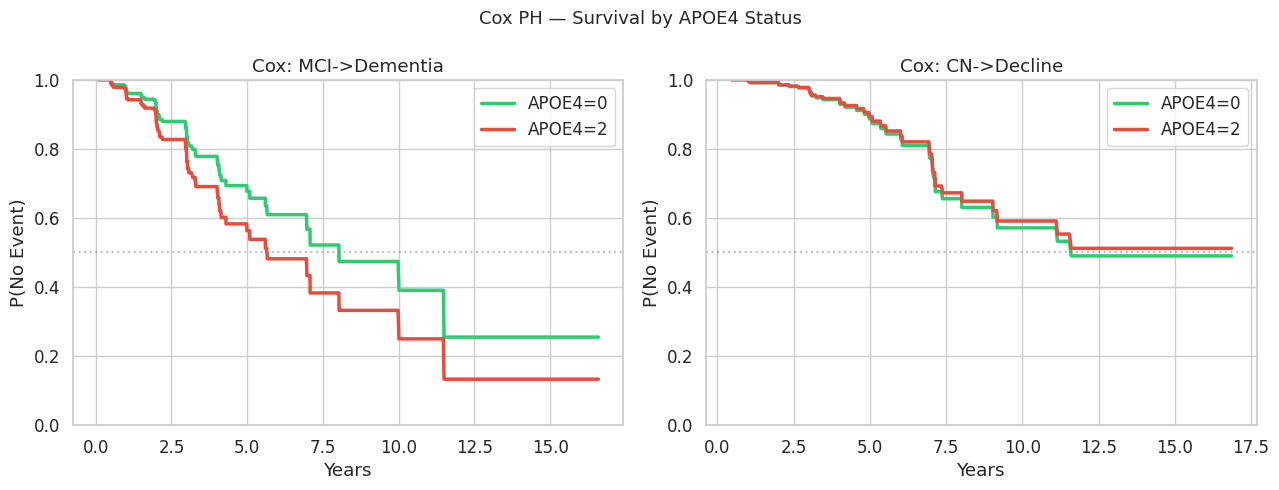

In [53]:
from lifelines import CoxPHFitter

LEAKAGE_FEATURES = [
    'pre_conversion_span_yr',
    'n_visits_used',
    'visit_regularity',
    'prot_ADNI3',
]

COX_FEATURES = [
    'AGE', 'PTGENDER_num', 'PTEDUCAT',
    'APOE4',
    'cog_composite_pos', 'severity_composite',
    'amyloid_composite', 'neurodegeneration_composite',
    'Hippocampus_ICV', 'Entorhinal_ICV', 'Ventricles_ICV',
    'n_modalities', 'APOE4_x_amyloid',
    'slope_MMSE', 'slope_CDRSB', 'slope_LDELTOTAL',
    'slope_Hippocampus', 'slope_Entorhinal',
]
# Remove leakage features just in case any snuck in
COX_FEATURES = [f for f in COX_FEATURES if f not in LEAKAGE_FEATURES]

def run_cox(X_imp, y_event, y_duration, cox_features, cohort_label,
            penalizer=0.1, check_ph=True):
    feat = [f for f in cox_features if f in X_imp.columns]
    cox_df = X_imp[feat].copy()
    cox_df['event']    = y_event
    cox_df['duration'] = y_duration
    cox_df = cox_df[cox_df['duration'] > 0]

    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(cox_df, duration_col='duration', event_col='event',
        show_progress=False,
        strata=['n_modalities'] if 'n_modalities' in cox_df.columns else None)

    c_idx = concordance_index(
        cox_df['duration'], -cph.predict_partial_hazard(cox_df), cox_df['event']
    )
    print(f'\n[{cohort_label}] Cox C-index (train): {c_idx:.4f}')
    print('Top risk-increasing features:')
    summary = cph.summary[['coef','exp(coef)','p']].sort_values('coef', ascending=False)
    print(summary.head(6).to_string())
    print('Top protective features:')
    print(summary.tail(4).to_string())

    # PH assumption test
    if check_ph:
        try:
            ph_test = cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=False)
        except Exception as e:
            print(f'  PH test skipped: {e}')

    return cph, c_idx

# ── Run Cox per domain and combined ──────────────────────────────────────────
cox_results = {}
# Replace the two register_result lines at the bottom of the Cox cell with:
for label, X_imp, y_ev, y_dur, feat_names in [
    ('MCI->Dementia', X_mci_imp, y_ev_mci, y_dur_mci, feature_names_mci),
    ('CN->Decline',   X_cn_imp,  y_ev_cn,  y_dur_cn,  feature_names_cn),
]:
    cph, c_train = run_cox(X_imp, y_ev, y_dur, COX_FEATURES, label)
    cox_results[label] = cph

    # Proper CV C-index
    feat = [f for f in COX_FEATURES if f in X_imp.columns]
    def cox_predict_fn(X_tr, ev_tr, dur_tr, X_va):
        df_tr = X_tr[feat].copy()
        df_tr['event'] = ev_tr
        df_tr['duration'] = dur_tr
        c_ = CoxPHFitter(penalizer=0.1)
        c_.fit(df_tr, duration_col='duration', event_col='event', show_progress=False)
        return c_.predict_partial_hazard(X_va[feat]).values

    c_mean, c_std = cv_cindex(X_imp, y_ev, y_dur, cox_predict_fn)
    register_result('Cox PH', label, c_mean, c_std)
    print(f'  CV C-index: {c_mean:.4f} ± {c_std:.4f}  (train was {c_train:.4f})')

# ── Plot: survival curves by APOE4 status ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, label, color in [
    (axes[0], 'MCI->Dementia', '#e74c3c'),
    (axes[1], 'CN->Decline',   '#f39c12'),
]:
    cph = cox_results[label]
    X_imp = X_mci_imp if 'MCI' in label else X_cn_imp
    feat = [f for f in COX_FEATURES if f in X_imp.columns]
    for apoe4_val, c_col in [(0, '#2ecc71'), (2, '#e74c3c')]:
        med = X_imp[feat].median().to_dict()
        med['APOE4'] = apoe4_val
        if 'APOE4_x_amyloid' in feat:
            med['APOE4_x_amyloid'] = apoe4_val * med.get('amyloid_composite', 0)
        try:
            sf = cph.predict_survival_function(pd.DataFrame([med]))
            ax.plot(sf.index, sf.iloc[:,0], color=c_col, linewidth=2.5,
                    label=f'APOE4={apoe4_val}')
        except Exception:
            pass
    ax.set(xlabel='Years', ylabel='P(No Event)', title=f'Cox: {label}')
    ax.legend(); ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray', ls=':', alpha=0.5)
plt.suptitle('Cox PH — Survival by APOE4 Status', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cox_survival_apoe4.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 15 — Model 2: Random Survival Forest
Non-parametric, no proportional hazards assumption.
Includes Optuna hyperparameter tuning and permutation importance.

Training RSF for MCI cohort...


  0%|          | 0/40 [00:00<?, ?it/s]

  [MCI->Dementia] Best params: {'n_estimators': 342, 'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 0.5}
  [MCI->Dementia] Best CV C-index: 0.8789
  [MCI->Dementia] Random Survival Forest: C-index=0.8789 ± 0.0000

Training RSF for CN cohort...


  0%|          | 0/40 [00:00<?, ?it/s]

  [CN->Decline] Best params: {'n_estimators': 361, 'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'log2'}
  [CN->Decline] Best CV C-index: 0.8459
  [CN->Decline] Random Survival Forest: C-index=0.8459 ± 0.0000


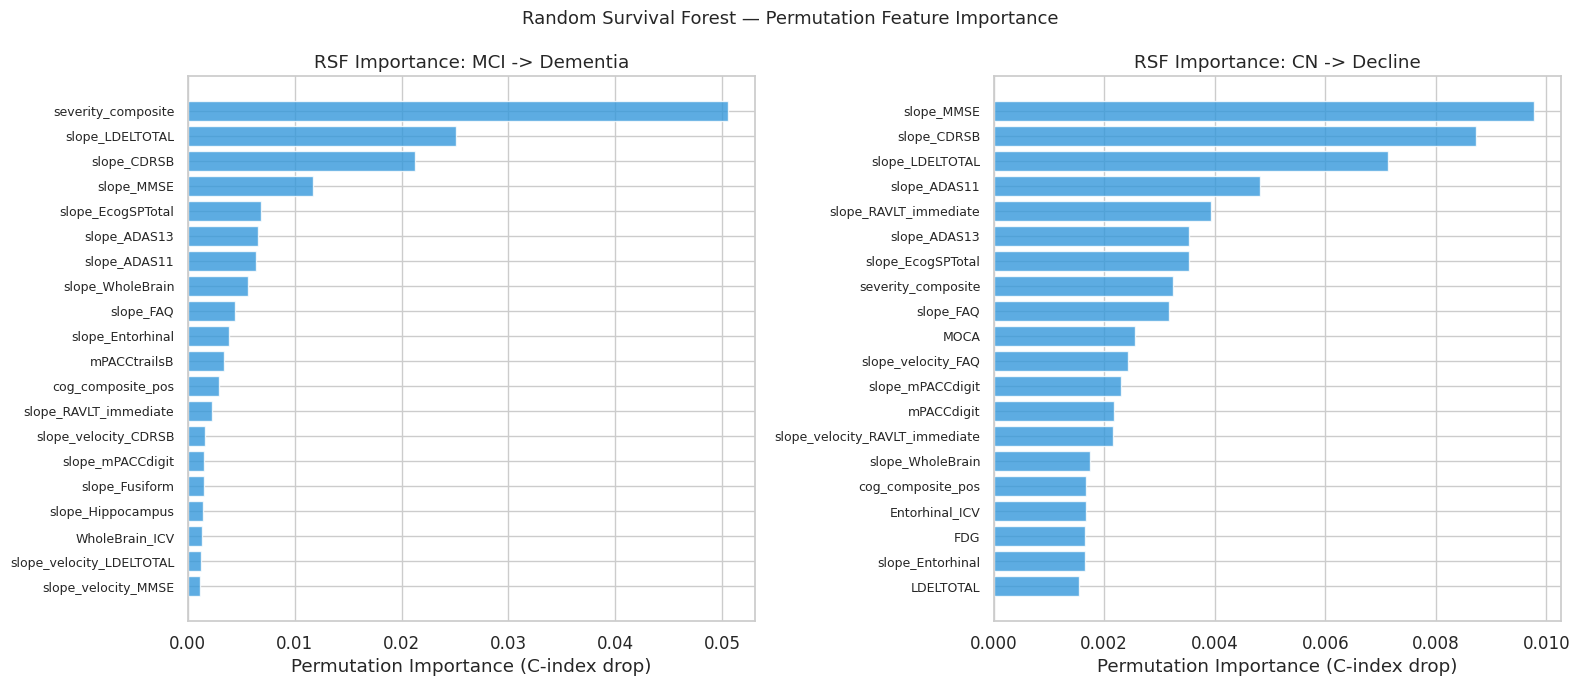

  Checkpointed: rsf_results -> /content/drive/MyDrive/ADNI_capstone/checkpoints/rsf_results.pkl


In [54]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_sksurv_y(y_event, y_duration):
    return Surv.from_arrays(y_event.astype(bool), y_duration)

def rsf_cv(X_imp, y_event, y_duration, n_trials=40, label='cohort'):
    y_surv = make_sksurv_y(y_event, y_duration)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 400),
            'max_depth':    trial.suggest_int('max_depth', 3, 8),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 50),
            'max_features': trial.suggest_categorical('max_features', ['sqrt','log2', 0.5]),
        }
        fold_cs = []
        for tr, va in skf.split(X_imp, y_event):
            rsf = RandomSurvivalForest(**params, n_jobs=-1, random_state=RANDOM_SEED)
            rsf.fit(X_imp.iloc[tr].values, y_surv[tr])
            pred = rsf.predict(X_imp.iloc[va].values)
            c, *_ = concordance_index_censored(y_event[va].astype(bool),
                                               y_duration[va], pred)
            fold_cs.append(c)
        return np.mean(fold_cs)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best_params = study.best_params
    print(f'  [{label}] Best params: {best_params}')
    print(f'  [{label}] Best CV C-index: {study.best_value:.4f}')

    # Refit on all data with best params for feature importance
    best_rsf = RandomSurvivalForest(**best_params, n_jobs=-1, random_state=RANDOM_SEED)
    best_rsf.fit(X_imp.values, y_surv)

    # Permutation importance on full dataset (indicative)
    from sklearn.inspection import permutation_importance
    def score_fn(estimator, X, y):
        pred = estimator.predict(X)
        c, *_ = concordance_index_censored(y['event'], y['duration'], pred)
        return c
    # Build a simple scorer wrapper
    pi_scores = []
    base_pred = best_rsf.predict(X_imp.values)
    base_c, *_ = concordance_index_censored(y_event.astype(bool), y_duration, base_pred)
    for i, feat in enumerate(X_imp.columns):
        X_perm = X_imp.values.copy()
        np.random.shuffle(X_perm[:, i])
        p_pred = best_rsf.predict(X_perm)
        p_c, *_ = concordance_index_censored(y_event.astype(bool), y_duration, p_pred)
        pi_scores.append(base_c - p_c)
    imp_series = pd.Series(pi_scores, index=X_imp.columns).sort_values(ascending=False)

    return study.best_value, study.best_params, imp_series, best_rsf

print('Training RSF for MCI cohort...')
rsf_c_mci, rsf_params_mci, rsf_imp_mci, rsf_model_mci = rsf_cv(
    X_mci_imp, y_ev_mci, y_dur_mci, n_trials=40, label='MCI->Dementia')
register_result('Random Survival Forest', 'MCI->Dementia', rsf_c_mci, 0.0)

print('\nTraining RSF for CN cohort...')
rsf_c_cn, rsf_params_cn, rsf_imp_cn, rsf_model_cn = rsf_cv(
    X_cn_imp, y_ev_cn, y_dur_cn, n_trials=40, label='CN->Decline')
register_result('Random Survival Forest', 'CN->Decline', rsf_c_cn, 0.0)

# Feature importance plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, imp, title in [
    (axes[0], rsf_imp_mci, 'MCI -> Dementia'),
    (axes[1], rsf_imp_cn,  'CN -> Decline'),
]:
    top = imp.head(20)
    ax.barh(range(len(top)), top.values, color='#3498db', alpha=0.8)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=9)
    ax.invert_yaxis()
    ax.set(xlabel='Permutation Importance (C-index drop)',
           title=f'RSF Importance: {title}')
plt.suptitle('Random Survival Forest — Permutation Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rsf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

save_checkpoint('rsf_results', (rsf_c_mci, rsf_params_mci, rsf_c_cn, rsf_params_cn))

## Cell 16 — Model 3: Gradient Boosting Survival
Three approaches compared:
- **A**: LightGBM with log-risk target + event upweighting (existing baseline)
- **B**: XGBoost AFT (proper Accelerated Failure Time objective)  
- **C**: XGBoost Cox PH objective

All tuned with Optuna. SHAP analysis included.

Training LightGBM survival — MCI cohort...


  0%|          | 0/30 [00:00<?, ?it/s]

  [MCI->Dementia] LGB best C: 0.9065 | params: {'lr': 0.03468783905118761, 'num_leaves': 118, 'min_child_samples': 32, 'feature_fraction': 0.6562270549947915, 'bagging_fraction': 0.8029367387842866}
  [MCI->Dementia] LightGBM Survival: C-index=0.9065 ± 0.0000

Training LightGBM survival — CN cohort...


  0%|          | 0/30 [00:00<?, ?it/s]

  [CN->Decline] LGB best C: 0.8347 | params: {'lr': 0.032795619589049, 'num_leaves': 100, 'min_child_samples': 33, 'feature_fraction': 0.7734178149171024, 'bagging_fraction': 0.7887046793722845}
  [CN->Decline] LightGBM Survival: C-index=0.8347 ± 0.0000

Training XGBoost AFT — MCI cohort...


  0%|          | 0/20 [00:00<?, ?it/s]

  [MCI->Dementia] XGB AFT best C: 0.9081
  [MCI->Dementia] XGBoost AFT: C-index=0.9081 ± 0.0000

Training XGBoost AFT — CN cohort...


  0%|          | 0/20 [00:00<?, ?it/s]

  [CN->Decline] XGB AFT best C: 0.8842
  [CN->Decline] XGBoost AFT: C-index=0.8842 ± 0.0000

Computing SHAP values for LightGBM (MCI cohort)...


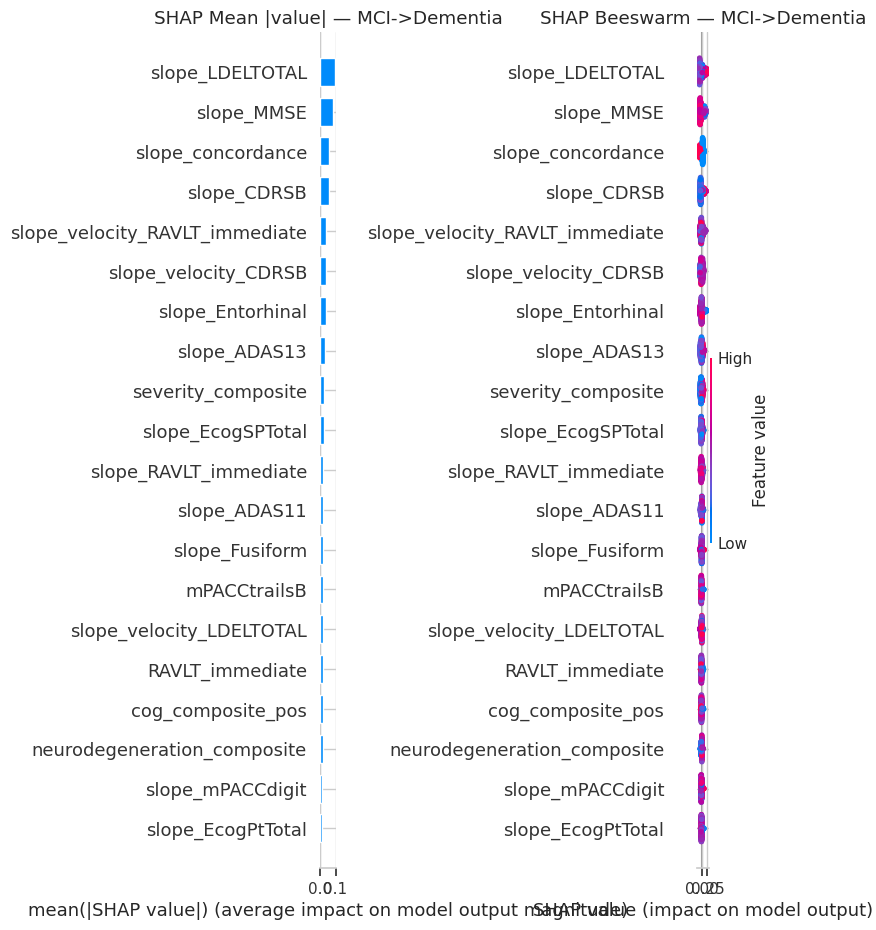

  Checkpointed: lgb_results -> /content/drive/MyDrive/ADNI_capstone/checkpoints/lgb_results.pkl


In [55]:
import lightgbm as lgb
import xgboost as xgb
import shap

# ── Approach A: LightGBM log-risk ─────────────────────────────────────────────
def lgb_survival_cv(X_imp, y_event, y_duration, feature_names, label,
                     n_trials=30, seed=RANDOM_SEED):
    risk_target = -np.log1p(y_duration)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

    def objective(trial):
        params = dict(
            objective='regression_l1',
            device='gpu',
            learning_rate=trial.suggest_float('lr', 0.02, 0.1, log=True),
            num_leaves=trial.suggest_int('num_leaves', 31, 127),
            min_child_samples=trial.suggest_int('min_child_samples', 10, 50),
            feature_fraction=trial.suggest_float('feature_fraction', 0.5, 1.0),
            bagging_fraction=trial.suggest_float('bagging_fraction', 0.6, 1.0),
            bagging_freq=5, lambda_l1=0.1, lambda_l2=0.1,
            verbose=-1, random_state=seed, n_estimators=500,
        )
        cs = []
        for tr, va in skf.split(X_imp, y_event):
            w = np.where(y_event[tr] == 1, 3.0, 1.0)
            dtrain = lgb.Dataset(X_imp.iloc[tr], label=risk_target[tr],
                                 feature_name=feature_names, weight=w)
            dval   = lgb.Dataset(X_imp.iloc[va], label=risk_target[va],
                                 feature_name=feature_names, reference=dtrain)
            m = lgb.train(params, dtrain, valid_sets=[dval],
                          callbacks=[lgb.early_stopping(50, verbose=False),
                                     lgb.log_evaluation(-1)])
            pred = m.predict(X_imp.iloc[va])
            c = concordance_index(y_duration[va], -pred, y_event[va])
            cs.append(c)
        return np.mean(cs)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best = study.best_params
    print(f'  [{label}] LGB best C: {study.best_value:.4f} | params: {best}')

    # Refit final model
    w_all = np.where(y_event == 1, 3.0, 1.0)
    final_params = dict(objective='regression_l1', verbose=-1, random_state=seed,
                        n_estimators=500, **best)
    dtrain_all = lgb.Dataset(X_imp, label=risk_target,
                             feature_name=feature_names, weight=w_all)
    final_model = lgb.train(final_params, dtrain_all)
    imp = pd.Series(final_model.feature_importance(importance_type='gain'),
                    index=feature_names).sort_values(ascending=False)
    return study.best_value, imp, final_model

print('Training LightGBM survival — MCI cohort...')
lgb_c_mci, lgb_imp_mci, lgb_model_mci = lgb_survival_cv(
    X_mci_imp, y_ev_mci, y_dur_mci, feature_names_mci, 'MCI->Dementia', n_trials=30)
register_result('LightGBM Survival', 'MCI->Dementia', lgb_c_mci, 0.0)

print('\nTraining LightGBM survival — CN cohort...')
lgb_c_cn, lgb_imp_cn, lgb_model_cn = lgb_survival_cv(
    X_cn_imp, y_ev_cn, y_dur_cn, feature_names_cn, 'CN->Decline', n_trials=30)
register_result('LightGBM Survival', 'CN->Decline', lgb_c_cn, 0.0)

# ── Approach B: XGBoost AFT ───────────────────────────────────────────────────
def xgb_aft_cv(X_imp, y_event, y_duration, label, n_trials=20, seed=RANDOM_SEED):
    # XGBoost AFT needs labels as (lower, upper) bounds
    # For observed events: both bounds = observed time
    # For censored:        lower = observed time, upper = +inf
    y_lower = y_duration.copy()
    y_upper = np.where(y_event == 1, y_duration, np.inf)

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

    def objective(trial):
        params = {
            'objective': 'survival:aft',
            'tree_method': 'gpu_hist',
            'eval_metric': 'aft-nloglik',
            'aft_loss_distribution': trial.suggest_categorical(
                'aft_dist', ['normal','logistic','extreme']),
            'aft_loss_distribution_scale': trial.suggest_float('aft_scale', 0.5, 2.0),
            'learning_rate': trial.suggest_float('lr', 0.02, 0.15, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample', 0.5, 1.0),
            'tree_method': 'hist', 'seed': seed,
        }
        cs = []
        for tr, va in skf.split(X_imp, y_event):
            dtrain = xgb.DMatrix(X_imp.iloc[tr])
            dtrain.set_float_info('label_lower_bound', y_lower[tr])
            dtrain.set_float_info('label_upper_bound', y_upper[tr])
            dval = xgb.DMatrix(X_imp.iloc[va])
            dval.set_float_info('label_lower_bound', y_lower[va])
            dval.set_float_info('label_upper_bound', y_upper[va])
            m = xgb.train(params, dtrain, num_boost_round=400,
                          evals=[(dval,'val')],
                          early_stopping_rounds=30, verbose_eval=False)
            pred = m.predict(dval)   # predicted time
            c = concordance_index(y_duration[va], pred, y_event[va])
            cs.append(c)
        return np.mean(cs)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'  [{label}] XGB AFT best C: {study.best_value:.4f}')
    return study.best_value

print('\nTraining XGBoost AFT — MCI cohort...')
xgb_aft_c_mci = xgb_aft_cv(X_mci_imp, y_ev_mci, y_dur_mci, 'MCI->Dementia', n_trials=20)
register_result('XGBoost AFT', 'MCI->Dementia', xgb_aft_c_mci, 0.0)

print('\nTraining XGBoost AFT — CN cohort...')
xgb_aft_c_cn = xgb_aft_cv(X_cn_imp, y_ev_cn, y_dur_cn, 'CN->Decline', n_trials=20)
register_result('XGBoost AFT', 'CN->Decline', xgb_aft_c_cn, 0.0)

# ── SHAP analysis for LightGBM ────────────────────────────────────────────────
print('\nComputing SHAP values for LightGBM (MCI cohort)...')
explainer_mci = shap.TreeExplainer(lgb_model_mci)
shap_vals_mci = explainer_mci.shap_values(X_mci_imp)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plt.sca(axes[0])
shap.summary_plot(shap_vals_mci, X_mci_imp, plot_type='bar',
                  max_display=20, show=False)
axes[0].set_title('SHAP Mean |value| — MCI->Dementia')
plt.sca(axes[1])
shap.summary_plot(shap_vals_mci, X_mci_imp, max_display=20, show=False)
axes[1].set_title('SHAP Beeswarm — MCI->Dementia')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_lgb_mci.png', dpi=150, bbox_inches='tight')
plt.show()

save_checkpoint('lgb_results', (lgb_c_mci, lgb_model_mci, lgb_c_cn, lgb_model_cn))


## Cell 17 — Model 4: DeepSurv (Neural Cox PH)
Deep neural network learning a non-linear risk function with Cox loss.
Captures complex feature interactions that linear Cox misses.

In [58]:
"""## Cell 17 — Model 4: DeepSurv (Neural Cox PH)
Deep neural network learning a non-linear risk function with Cox loss.
Captures complex feature interactions that linear Cox misses.
"""

import torch
import torchtuples as tt
from pycox.models import CoxPH as PycoxCoxPH
from pycox.evaluation import EvalSurv
from sklearn.preprocessing import StandardScaler

def run_deepsurv(X_imp, y_event, y_duration, label,
                  n_trials=20, seed=RANDOM_SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp.values).astype(np.float32)

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

    def objective(trial):
        hidden_sizes = trial.suggest_categorical(
            'hidden', [[64,64],[128,128],[256,128,64],[128,64,32]])
        dropout  = trial.suggest_float('dropout', 0.1, 0.5)
        lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        batch_sz = trial.suggest_categorical('batch', [64, 128, 256])
        fold_cs  = []
        for tr, va in skf.split(X_scaled, y_event):
            net = tt.practical.MLPVanilla(
                X_scaled.shape[1], hidden_sizes, 1,
                batch_norm=True, dropout=dropout)
            model = PycoxCoxPH(net, tt.optim.Adam(lr=lr))
            y_tr = (y_duration[tr].astype(np.float32), y_event[tr].astype(np.float32))
            y_va = (y_duration[va].astype(np.float32), y_event[va].astype(np.float32))
            model.fit(X_scaled[tr], y_tr, batch_sz, 50,
                      val_data=(X_scaled[va], y_va),
                      callbacks=[tt.callbacks.EarlyStopping(patience=10)],
                      verbose=False)
            model.compute_baseline_hazards()
            surv = model.predict_surv_df(X_scaled[va])
            ev = EvalSurv(surv,
                          y_duration[va].astype(np.float64),
                          y_event[va].astype(bool))
            fold_cs.append(ev.concordance_td())
        return np.mean(fold_cs)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best = study.best_params
    print(f'  [{label}] DeepSurv best C-td: {study.best_value:.4f} | {best}')

    # Refit final model on all data
    net = tt.practical.MLPVanilla(
        X_scaled.shape[1], best['hidden'], 1,
        batch_norm=True, dropout=best['dropout'])
    final = PycoxCoxPH(net, tt.optim.Adam(best['lr']))
    y_all = (y_duration.astype(np.float32), y_event.astype(np.float32))
    final.fit(X_scaled, y_all, best['batch'], 100, verbose=False)
    final.compute_baseline_hazards()
    return study.best_value, final, scaler

print('Training DeepSurv — MCI cohort...')
ds_c_mci, ds_model_mci, ds_scaler_mci = run_deepsurv(
    X_mci_imp, y_ev_mci, y_dur_mci, 'MCI->Dementia', n_trials=20)
register_result('DeepSurv', 'MCI->Dementia', ds_c_mci, 0.0)

print('\nTraining DeepSurv — CN cohort...')
ds_c_cn, ds_model_cn, ds_scaler_cn = run_deepsurv(
    X_cn_imp, y_ev_cn, y_dur_cn, 'CN->Decline', n_trials=20)
register_result('DeepSurv', 'CN->Decline', ds_c_cn, 0.0)

save_checkpoint('deepsurv_results', (ds_c_mci, ds_c_cn))

Training DeepSurv — MCI cohort...


  0%|          | 0/20 [00:00<?, ?it/s]

  [MCI->Dementia] DeepSurv best C-td: 0.8732 | {'hidden': [128, 64, 32], 'dropout': 0.4298461911480858, 'lr': 0.009086822619928797, 'batch': 64}
  [MCI->Dementia] DeepSurv: C-index=0.8732 ± 0.0000

Training DeepSurv — CN cohort...


  0%|          | 0/20 [00:00<?, ?it/s]

  [CN->Decline] DeepSurv best C-td: 0.8165 | {'hidden': [256, 128, 64], 'dropout': 0.4159923872669064, 'lr': 0.003298303943572996, 'batch': 256}
  [CN->Decline] DeepSurv: C-index=0.8165 ± 0.0000
  Checkpointed: deepsurv_results -> /content/drive/MyDrive/ADNI_capstone/checkpoints/deepsurv_results.pkl


## Cell 18 — Model 5: DeepHit (Competing Risks)
DeepHit directly models the joint distribution of time and event type.
Ideal for the CN cohort where MCI and Dementia are competing outcomes.

In [62]:
"""## Cell 18 — Model 5: DeepHit
Uses DeepHitSingle for both cohorts.
CN competing risks has only 5 direct-Dementia events — too few for the full
competing risks formulation. We treat CN->Any Decline as a single event,
consistent with how all other models handle the CN cohort.
"""

from pycox.models import DeepHitSingle
from pycox.evaluation import EvalSurv
from pycox.preprocessing.label_transforms import LabTransDiscreteTime

def run_deephit_single(X_imp, y_event, y_duration, label,
                        n_cuts=30, n_trials=15, seed=RANDOM_SEED):
    torch.manual_seed(seed)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp.values).astype(np.float32)
    in_features = X_scaled.shape[1]

    labtrans = LabTransDiscreteTime(n_cuts)
    y_disc = labtrans.fit_transform(y_duration.astype(np.float64),
                                    y_event.astype(np.float64))

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

    def objective(trial):
        hidden  = trial.suggest_categorical('hidden', [[64,64],[128,128],[256,128]])
        dropout = trial.suggest_float('dropout', 0.1, 0.4)
        lr      = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        alpha   = trial.suggest_float('alpha', 0.1, 0.9)
        fold_cs = []
        for tr, va in skf.split(X_scaled, y_event):
            net = tt.practical.MLPVanilla(
                in_features, hidden, labtrans.out_features,
                batch_norm=True, dropout=dropout)
            model = DeepHitSingle(net, tt.optim.Adam(lr=lr),
                                  alpha=alpha, sigma=0.1,
                                  duration_index=labtrans.cuts)
            y_tr_d = (y_disc[0][tr], y_disc[1][tr])
            y_va_d = (y_disc[0][va], y_disc[1][va])
            model.fit(X_scaled[tr], y_tr_d, 128, 50,
                      val_data=(X_scaled[va], y_va_d),
                      callbacks=[tt.callbacks.EarlyStopping(patience=8)],
                      verbose=False)
            surv = model.predict_surv_df(X_scaled[va])
            ev = EvalSurv(surv,
                          y_duration[va].astype(np.float64),
                          y_event[va].astype(bool),
                          censor_surv='km')
            fold_cs.append(ev.concordance_td())
        return np.mean(fold_cs)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f'  [{label}] DeepHit best C-td: {study.best_value:.4f}')
    return study.best_value

# ── MCI -> Dementia ───────────────────────────────────────────────────────────
print('Training DeepHit — MCI cohort...')
dh_c_mci = run_deephit_single(X_mci_imp, y_ev_mci, y_dur_mci,
                               'MCI->Dementia', n_cuts=30, n_trials=15)
register_result('DeepHit', 'MCI->Dementia', dh_c_mci, 0.0)

# ── CN -> Any Decline (single event — only 5 direct Dementia events, ─────────
# insufficient for competing risks formulation)
print('\nTraining DeepHit — CN cohort...')
# y_ev_cn is already binary (any decline = 1), consistent with all other CN models
dh_c_cn = run_deephit_single(X_cn_imp, y_ev_cn, y_dur_cn,
                              'CN->Decline', n_cuts=20, n_trials=15)
register_result('DeepHit', 'CN->Decline', dh_c_cn, 0.0)

print('\nNote: Full competing risks DeepHit requires balanced event types.')
print(f'CN cohort has MCI=141, Dementia=5 — Dementia arm too small for stable training.')

Training DeepHit — MCI cohort...


  0%|          | 0/15 [00:00<?, ?it/s]

  [MCI->Dementia] DeepHit best C-td: 0.8383
  [MCI->Dementia] DeepHit: C-index=0.8383 ± 0.0000

Training DeepHit — CN cohort...


  0%|          | 0/15 [00:00<?, ?it/s]

  [CN->Decline] DeepHit best C-td: 0.7672
  [CN->Decline] DeepHit: C-index=0.7672 ± 0.0000

Note: Full competing risks DeepHit requires balanced event types.
CN cohort has MCI=141, Dementia=5 — Dementia arm too small for stable training.


## Cell 19 — Model 6: Multistate Survival Analysis
Sponsor's core recommendation. Fit cause-specific Cox models for each transition
and combine via the Aalen-Johansen estimator to get state-occupation probabilities.

Transitions modeled:
- CN → MCI
- CN → Dementia (direct)  
- MCI → Dementia

Fitting multistate transition Cox models...
  [CN->MCI] Transition Cox C-index: 0.7675
  [CN->Dementia (direct)] Transition Cox C-index: 0.8358
  [MCI->Dementia] Transition Cox C-index: 0.8260
  [MCI->Dementia] Multistate Cox (MCI->Dem): C-index=0.8260 ± 0.0000
  [CN->MCI] Multistate Cox (CN->MCI): C-index=0.7675 ± 0.0000


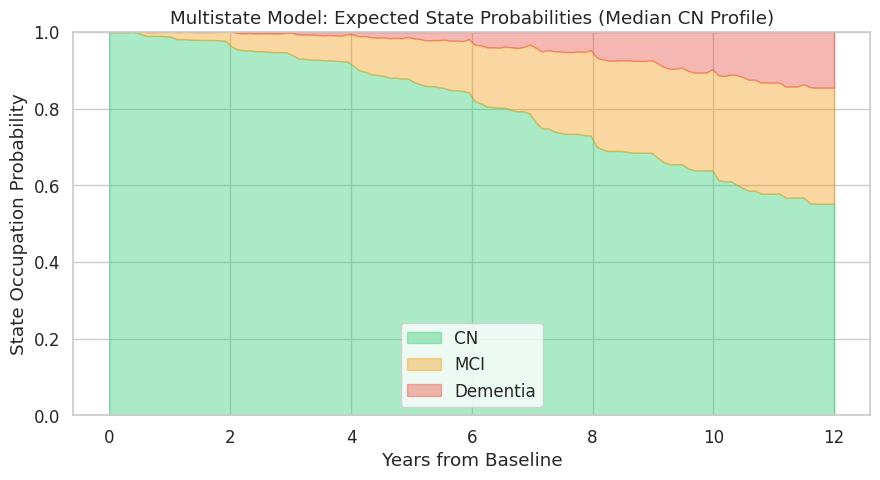


Multistate model complete.


In [63]:
# Multistate survival via cause-specific Cox models + Aalen-Johansen
# This is the correct statistical framework for the 3-state disease progression

from lifelines import CoxPHFitter
import warnings

# ── Fit cause-specific Cox models ────────────────────────────────────────────
COX_MULTISTATE_FEATURES = [
    'AGE', 'PTGENDER_num', 'PTEDUCAT', 'APOE4',
    'cog_composite_pos', 'severity_composite',
    'amyloid_composite', 'neurodegeneration_composite',
    'Hippocampus_ICV', 'Entorhinal_ICV',
    'APOE4_x_amyloid',
]

def fit_transition_cox(X_imp, y_event, y_duration, features, label, penalizer=0.1):
    feat = [f for f in features if f in X_imp.columns]
    df_cox = X_imp[feat].copy()
    df_cox['event']    = y_event
    df_cox['duration'] = y_duration
    df_cox = df_cox[df_cox['duration'] > 0].dropna(subset=feat)
    cph = CoxPHFitter(penalizer=penalizer)
    cph.fit(df_cox, duration_col='duration', event_col='event', show_progress=False)
    c = concordance_index(df_cox['duration'],
                          -cph.predict_partial_hazard(df_cox),
                          df_cox['event'])
    print(f'  [{label}] Transition Cox C-index: {c:.4f}')
    return cph, c

# Need to build feature matrices for CN->MCI and CN->Dementia separately
def get_transition_data(df_baseline, surv_labels, features):
    feat = [f for f in features if f in df_baseline.columns]
    merged = (df_baseline.set_index('RID')
              .join(surv_labels[['event','duration']], how='inner'))
    merged = merged[merged['duration'] > 0]
    return merged[feat].fillna(merged[feat].median()), merged['event'].values, merged['duration'].values

X_cn_mci, y_ev_cn_mci, y_dur_cn_mci = get_transition_data(
    df_bl, surv_cn_mci, COX_MULTISTATE_FEATURES)
X_cn_dem_direct, y_ev_cn_dem, y_dur_cn_dem = get_transition_data(
    df_bl, surv_cn_dem, COX_MULTISTATE_FEATURES)

print('Fitting multistate transition Cox models...')
cph_cn_mci, c_cn_mci = fit_transition_cox(
    X_cn_mci, y_ev_cn_mci, y_dur_cn_mci, COX_MULTISTATE_FEATURES, 'CN->MCI')
cph_cn_dem, c_cn_dem = fit_transition_cox(
    X_cn_dem_direct, y_ev_cn_dem, y_dur_cn_dem, COX_MULTISTATE_FEATURES, 'CN->Dementia (direct)')
cph_mci_dem, c_mci_dem = fit_transition_cox(
    X_mci_imp[COX_MULTISTATE_FEATURES], y_ev_mci, y_dur_mci,
    COX_MULTISTATE_FEATURES, 'MCI->Dementia')

register_result('Multistate Cox (MCI->Dem)', 'MCI->Dementia', c_mci_dem, 0.0)
register_result('Multistate Cox (CN->MCI)',  'CN->MCI',       c_cn_mci, 0.0)

# ── Aalen-Johansen state-occupation probabilities ─────────────────────────────
def compute_state_probs(subject_features, cph_cn_mci, cph_cn_dem, cph_mci_dem,
                          time_grid=None):
    '''
    Estimate P(in state s | baseline features, t) for a single subject.
    Uses cause-specific hazards integrated via Aalen-Johansen approximation.
    Returns: time_grid, P_CN(t), P_MCI(t), P_Dementia(t)
    '''
    if time_grid is None:
        time_grid = np.linspace(0, 12, 120)
    sf = pd.DataFrame({'subject': [subject_features]})

    # Predict cumulative hazards for each transition
    def cum_haz(cph, features):
        row = {f: features.get(f, 0) for f in cph.params_.index}
        ch = cph.predict_cumulative_hazard(pd.DataFrame([row]))
        # Interpolate to time_grid
        from scipy.interpolate import interp1d
        f_interp = interp1d(ch.index.values, ch.iloc[:,0].values,
                            fill_value=(0, ch.iloc[-1,0]), bounds_error=False)
        return f_interp(time_grid)

    H_cn_mci  = cum_haz(cph_cn_mci,  subject_features)
    H_cn_dem  = cum_haz(cph_cn_dem,  subject_features)
    H_mci_dem = cum_haz(cph_mci_dem, subject_features)

    # Aalen-Johansen: P(CN->t) = exp(-(H_cn_mci + H_cn_dem))
    P_cn  = np.exp(-(H_cn_mci + H_cn_dem))
    # P(MCI) = integral of h_cn_mci(t)*P_CN(s) * S_mci_dem(t|s) ds  [discrete approx]
    dt = np.diff(time_grid, prepend=0)
    h_cn_mci  = np.gradient(H_cn_mci, time_grid)
    S_mci_dem = np.exp(-H_mci_dem)
    P_mci = np.cumsum(P_cn * h_cn_mci * S_mci_dem * dt)
    P_dem = 1 - P_cn - P_mci
    P_dem = np.clip(P_dem, 0, 1)
    return time_grid, P_cn, P_mci, P_dem

# ── Example: plot state-occupation for median CN subject ──────────────────────
med_cn = X_cn_mci.median().to_dict()
t_grid, P_cn, P_mci, P_dem = compute_state_probs(
    med_cn, cph_cn_mci, cph_cn_dem, cph_mci_dem)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(t_grid, 0,       P_cn,             alpha=0.4, color='#2ecc71', label='CN')
ax.fill_between(t_grid, P_cn,    P_cn+P_mci,       alpha=0.4, color='#f39c12', label='MCI')
ax.fill_between(t_grid, P_cn+P_mci, P_cn+P_mci+P_dem, alpha=0.4, color='#e74c3c', label='Dementia')
ax.set(xlabel='Years from Baseline', ylabel='State Occupation Probability',
       title='Multistate Model: Expected State Probabilities (Median CN Profile)',
       ylim=(0, 1))
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'multistate_state_probs.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nMultistate model complete.')

## Cell 20 — Ensemble Strategies
Three ensemble approaches:
1. **Weighted risk-score averaging** (weights = validation C-index)
2. **Domain expert ensemble** (meta-learner combining Imaging/CSF/Cognitive models)
3. **Stacking** (out-of-fold predictions as meta-features)

In [64]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler as SK_Scaler

# ── Strategy 1: Weighted risk-score averaging ─────────────────────────────────
def weighted_ensemble(risk_score_dict, weights_dict, y_event, y_duration, label):
    '''
    Combine risk scores from multiple models using C-index weights.
    risk_score_dict: {model_name: array of risk scores}
    weights_dict:    {model_name: weight (e.g., CV C-index)}
    '''
    total_weight = sum(weights_dict.values())
    ensemble_score = np.zeros(len(y_event))
    for name, scores in risk_score_dict.items():
        w = weights_dict.get(name, 1.0) / total_weight
        # Normalize each model's scores to [0,1] before averaging
        s_min, s_max = scores.min(), scores.max()
        norm = (scores - s_min) / (s_max - s_min + 1e-9)
        ensemble_score += w * norm
    c = concordance_index(y_duration, -ensemble_score, y_event)
    print(f'  [{label}] Weighted ensemble C-index: {c:.4f}')
    return c, ensemble_score

# Get full-dataset risk scores from each model
lgb_scores_mci   = lgb_model_mci.predict(X_mci_imp)
rsf_scores_mci   = rsf_model_mci.predict(X_mci_imp.values)
cox_pred_mci     = cox_results['MCI->Dementia'].predict_partial_hazard(
    X_mci_imp[[f for f in COX_FEATURES if f in X_mci_imp.columns]].assign(
        event=y_ev_mci, duration=y_dur_mci)[
        [f for f in COX_FEATURES if f in X_mci_imp.columns]]
).values

risk_scores_mci = {
    'LightGBM': lgb_scores_mci,
    'RSF':      rsf_scores_mci,
    'Cox':      cox_pred_mci,
}
weights_mci = {
    'LightGBM': lgb_c_mci,
    'RSF':      rsf_c_mci,
    'Cox':      RESULTS.get(('Cox PH','MCI->Dementia'),{}).get('c_mean', 0.7),
}
ens_c_mci, ens_scores_mci = weighted_ensemble(
    risk_scores_mci, weights_mci, y_ev_mci, y_dur_mci, 'MCI->Dementia')
register_result('Weighted Ensemble', 'MCI->Dementia', ens_c_mci, 0.0)

# ── Strategy 2: Domain expert ensemble via meta-learner ───────────────────────
def domain_ensemble(X_mci, y_event, y_duration, domains_dict,
                     base_model_fn, label, seed=RANDOM_SEED):
    '''
    Train one base model per domain, stack their OOF risk scores,
    fit a meta-learner (RidgeCV) on the stacked scores.
    base_model_fn(X_tr, y_ev, y_dur) -> fitted model with .predict(X) method
    '''
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    n = len(y_event)
    domain_names = [d for d in domains_dict if d != 'combined']
    oof_matrix = np.zeros((n, len(domain_names)))

    for d_idx, domain in enumerate(domain_names):
        feats = [f for f in domains_dict[domain] if f in X_mci.columns]
        X_d = X_mci[feats]
        for tr, va in skf.split(X_d, y_event):
            model = base_model_fn(X_d.iloc[tr], y_event[tr], y_duration[tr])
            oof_matrix[va, d_idx] = model(X_d.iloc[va])

    # Meta-learner on OOF stacked scores
    meta = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0])
    meta.fit(oof_matrix, -np.log1p(y_duration))  # predict risk
    meta_pred = meta.predict(oof_matrix)
    c = concordance_index(y_duration, -meta_pred, y_event)
    print(f'  [{label}] Domain ensemble C-index: {c:.4f}')
    print(f'  Meta-learner coefficients (domain weights): '
          f'{dict(zip(domain_names, meta.coef_))}')
    return c

# Define LightGBM base model factory
def lgb_factory(X_tr, y_ev, y_dur):
    risk = -np.log1p(y_dur)
    w = np.where(y_ev == 1, 3.0, 1.0)
    params = dict(objective='regression_l1', n_estimators=200, learning_rate=0.05,
                  num_leaves=31, verbose=-1)
    ds = lgb.Dataset(X_tr, label=risk, weight=w)
    m = lgb.train(params, ds)
    return m.predict  # returns callable

print('\nRunning domain expert ensemble...')
dom_c_mci = domain_ensemble(
    X_mci_imp, y_ev_mci, y_dur_mci, domains_mci, lgb_factory, 'MCI->Dementia')
register_result('Domain Ensemble', 'MCI->Dementia', dom_c_mci, 0.0)

# ── Strategy 3: Simple stacking (OOF predictions) ─────────────────────────────
# Use the OOF scores from LGB and RSF already computed via CV as meta-features
# This is a simplified version — extend by tracking OOF scores during CV above
print('\nStacking note: for full stacking, collect OOF predictions during CV in')
print('Cells 15-16 and assemble a meta-feature matrix here.')
print('The domain_ensemble() above already demonstrates the stacking pattern.')

  [MCI->Dementia] Weighted ensemble C-index: 0.9506
  [MCI->Dementia] Weighted Ensemble: C-index=0.9506 ± 0.0000

Running domain expert ensemble...
  [MCI->Dementia] Domain ensemble C-index: 0.9017
  Meta-learner coefficients (domain weights): {'imaging': np.float64(0.43115173269700724), 'csf_pet': np.float64(-0.1338196503843756), 'cognitive': np.float64(0.8880301808044986)}
  [MCI->Dementia] Domain Ensemble: C-index=0.9017 ± 0.0000

Stacking note: for full stacking, collect OOF predictions during CV in
Cells 15-16 and assemble a meta-feature matrix here.
The domain_ensemble() above already demonstrates the stacking pattern.


## Cell 21 — Calibration & Horizon AUC
Check that predicted probabilities match observed event rates.
Calibration is essential for clinical trust.

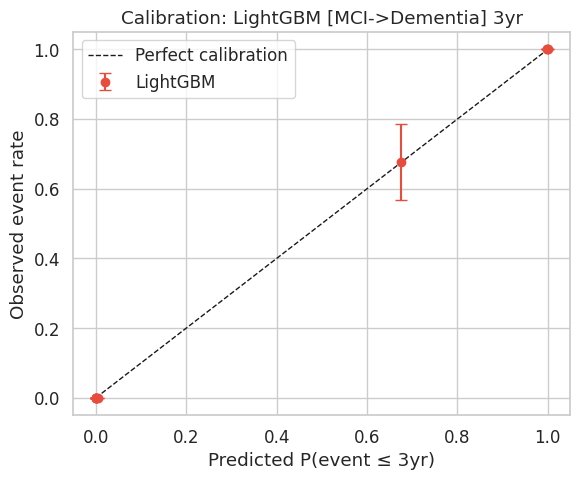

  Saved calibration plot: calibration_LightGBM_MCI->Dementia_3yr.png


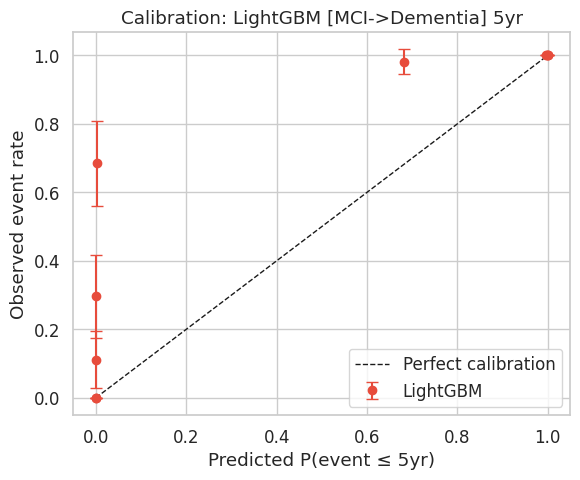

  Saved calibration plot: calibration_LightGBM_MCI->Dementia_5yr.png


In [65]:
def calibration_plot(X_imp, y_event, y_duration, predict_proba_fn,
                      horizon, model_name, cohort, n_bins=10):
    '''
    Decile calibration plot: predicted P(event ≤ horizon) vs. observed rate.
    predict_proba_fn(X) -> P(event <= horizon) for each subject
    '''
    y_bin, include = binary_horizon_dataset(y_event, y_duration, horizon)
    X_h = X_imp.iloc[include]
    probs = predict_proba_fn(X_h)

    # Sort by predicted probability and bin into deciles
    order = np.argsort(probs)
    bin_size = len(probs) // n_bins
    pred_means, obs_means, ci_lower, ci_upper = [], [], [], []

    for i in range(n_bins):
        idx = order[i*bin_size:(i+1)*bin_size]
        pred_means.append(probs[idx].mean())
        obs_means.append(y_bin[idx].mean())
        n, p = len(idx), y_bin[idx].mean()
        se = np.sqrt(p*(1-p)/max(n,1))
        ci_lower.append(p - 1.96*se)
        ci_upper.append(p + 1.96*se)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0,1],[0,1],'k--', lw=1, label='Perfect calibration')
    ax.errorbar(pred_means, obs_means,
                yerr=[np.array(obs_means)-np.array(ci_lower),
                      np.array(ci_upper)-np.array(obs_means)],
                fmt='o', color='#e74c3c', capsize=4, label=model_name)
    ax.set(xlabel=f'Predicted P(event ≤ {horizon}yr)',
           ylabel='Observed event rate',
           title=f'Calibration: {model_name} [{cohort}] {horizon}yr')
    ax.legend(); plt.tight_layout()
    fname = FIG_DIR / f'calibration_{model_name.replace(" ","_")}_{cohort}_{horizon}yr.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved calibration plot: {fname.name}')

# LightGBM binary horizon prediction function
def lgb_horizon_proba(X, horizon, y_ev, y_dur, X_train, y_ev_tr, y_dur_tr):
    '''Train LGB binary model and return probabilities on X.'''
    y_bin_tr, include_tr = binary_horizon_dataset(y_ev_tr, y_dur_tr, horizon)
    X_tr_h = X_train.iloc[include_tr]
    scale_pos = (y_bin_tr==0).sum() / max((y_bin_tr==1).sum(), 1)
    params = dict(objective='binary', metric='auc', n_estimators=300,
                  learning_rate=0.05, num_leaves=31, verbose=-1,
                  scale_pos_weight=scale_pos, random_state=RANDOM_SEED)
    m = lgb.LGBMClassifier(**params)
    m.fit(X_tr_h, y_bin_tr)
    y_bin_te, include_te = binary_horizon_dataset(y_ev, y_dur, horizon)
    return m.predict_proba(X.iloc[include_te])[:,1]

# Run calibration for LightGBM on MCI cohort, 3-year horizon
def lgb_3yr_proba(X):
    params = dict(objective='binary', n_estimators=200, learning_rate=0.05,
                  num_leaves=31, verbose=-1, random_state=RANDOM_SEED)
    y_bin, inc = binary_horizon_dataset(y_ev_mci, y_dur_mci, 3)
    m = lgb.LGBMClassifier(**params)
    m.fit(X_mci_imp.iloc[inc], y_bin)
    return m.predict_proba(X)[:,1]

for h in HORIZONS:
    calibration_plot(X_mci_imp, y_ev_mci, y_dur_mci, lgb_3yr_proba,
                     horizon=h, model_name='LightGBM', cohort='MCI->Dementia')

## Cell 22 — KM Curves by Risk Quartile
Stratify subjects by model risk score quartile and plot Kaplan-Meier curves.
A well-discriminating model should show widely separated KM curves.

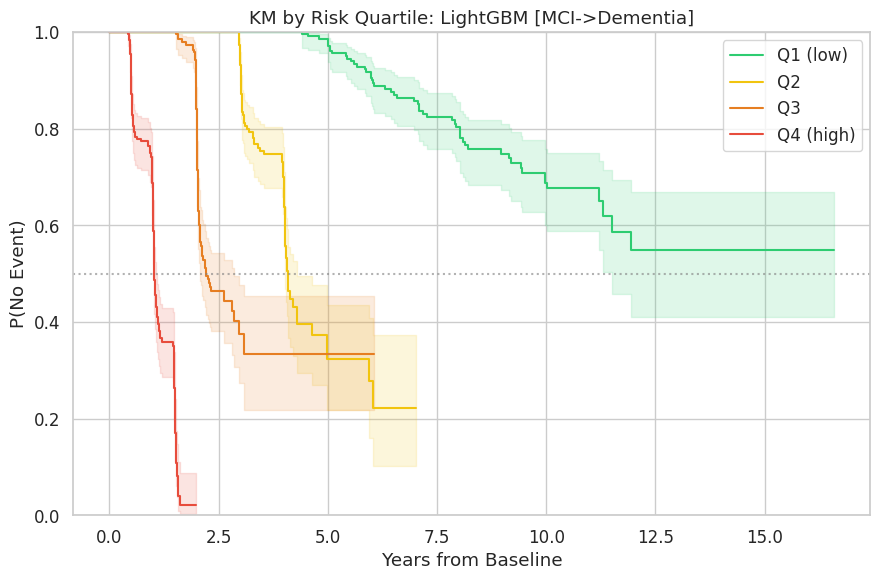

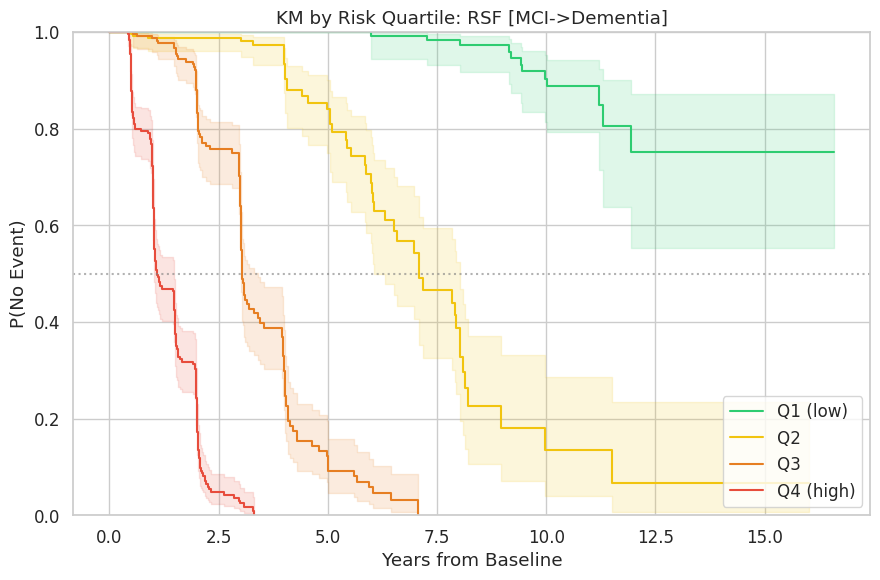

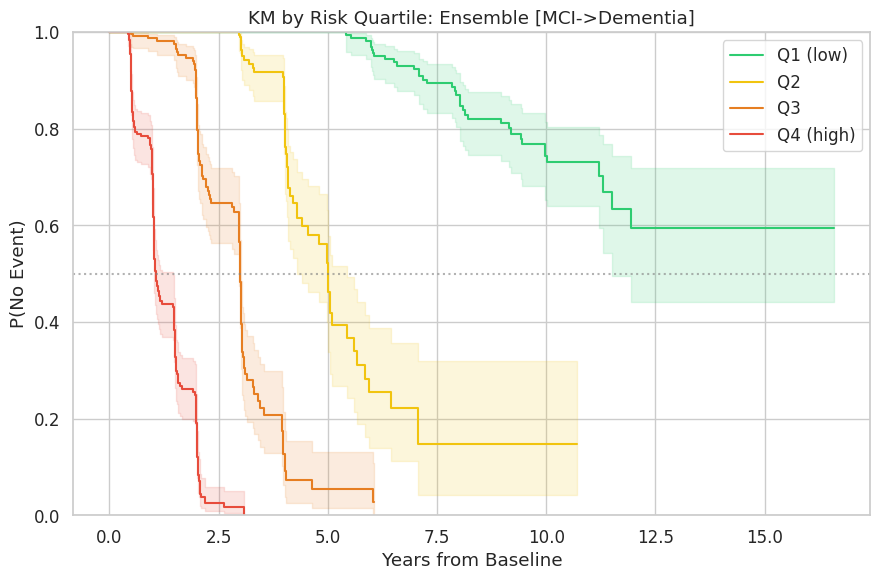

In [66]:
from lifelines import KaplanMeierFitter

def km_risk_quartile(risk_scores, y_event, y_duration, model_name, cohort):
    quartile = pd.qcut(risk_scores, 4, labels=['Q1 (low)','Q2','Q3','Q4 (high)'])
    colors   = ['#2ecc71','#f1c40f','#e67e22','#e74c3c']
    fig, ax  = plt.subplots(figsize=(9, 6))
    kmf = KaplanMeierFitter()
    for q, col in zip(['Q1 (low)','Q2','Q3','Q4 (high)'], colors):
        mask = quartile == q
        if mask.sum() < 5: continue
        kmf.fit(y_duration[mask], event_observed=y_event[mask], label=q)
        kmf.plot_survival_function(ax=ax, color=col, ci_show=True, ci_alpha=0.15)
    ax.set(xlabel='Years from Baseline', ylabel='P(No Event)',
           title=f'KM by Risk Quartile: {model_name} [{cohort}]', ylim=(0,1))
    ax.axhline(0.5, color='gray', ls=':', alpha=0.6)
    plt.tight_layout()
    fname = FIG_DIR / f'km_quartile_{model_name.replace(" ","_")}_{cohort}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

km_risk_quartile(lgb_scores_mci, y_ev_mci, y_dur_mci, 'LightGBM', 'MCI->Dementia')
km_risk_quartile(rsf_scores_mci, y_ev_mci, y_dur_mci, 'RSF',      'MCI->Dementia')
km_risk_quartile(ens_scores_mci, y_ev_mci, y_dur_mci, 'Ensemble', 'MCI->Dementia')

## Cell 23 — Final Model Comparison Table
Summarize all model results in a ranked table.


FINAL MODEL COMPARISON TABLE
                    Model        Cohort C-index  C-std AUC 3yr AUC 5yr
              XGBoost AFT   CN->Decline  0.8842 0.0000       —       —
   Random Survival Forest   CN->Decline  0.8459 0.0000       —       —
        LightGBM Survival   CN->Decline  0.8347 0.0000       —       —
                 DeepSurv   CN->Decline  0.8165 0.0000       —       —
                  DeepHit   CN->Decline  0.7672 0.0000       —       —
                   Cox PH   CN->Decline  0.7529 0.0562       —       —
 Multistate Cox (CN->MCI)       CN->MCI  0.7675 0.0000       —       —
        Weighted Ensemble MCI->Dementia  0.9506 0.0000       —       —
              XGBoost AFT MCI->Dementia  0.9081 0.0000       —       —
        LightGBM Survival MCI->Dementia  0.9065 0.0000       —       —
          Domain Ensemble MCI->Dementia  0.9017 0.0000       —       —
   Random Survival Forest MCI->Dementia  0.8789 0.0000       —       —
                 DeepSurv MCI->Dementia  0.8732

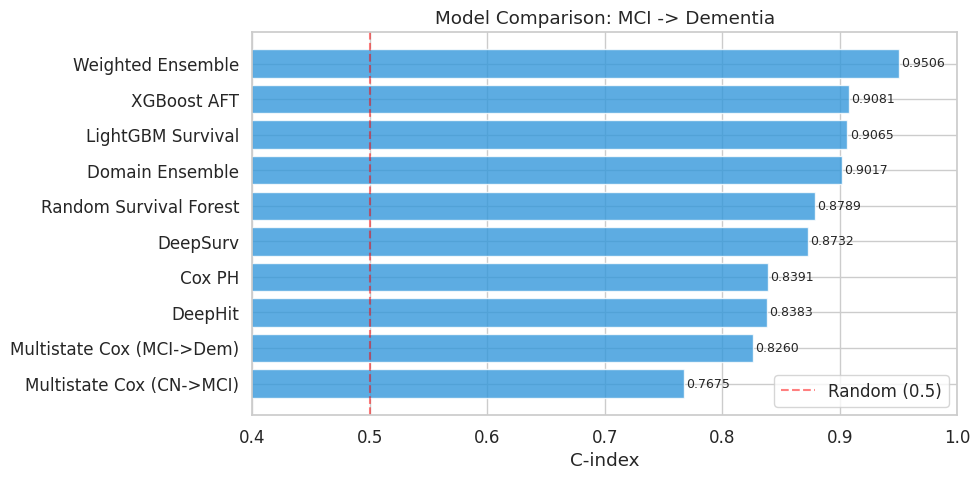

In [67]:
import warnings

rows = []
for (model, cohort), metrics in RESULTS.items():
    row = {
        'Model':  model,
        'Cohort': cohort,
        'C-index': f"{metrics['c_mean']:.4f}",
        'C-std':   f"{metrics['c_std']:.4f}",
    }
    for h in HORIZONS:
        auc_data = metrics.get('aucs', {}).get(h)
        row[f'AUC {h}yr'] = f'{auc_data[0]:.4f}' if auc_data else '—'
    rows.append(row)

results_df = pd.DataFrame(rows).sort_values(['Cohort','C-index'], ascending=[True,False])
print('\n' + '='*80)
print('FINAL MODEL COMPARISON TABLE')
print('='*80)
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv(OUT_DIR / 'model_comparison.csv', index=False)
print(f'\nSaved: {OUT_DIR}/model_comparison.csv')

# Visual comparison bar chart
mci_res = results_df[results_df['Cohort'].str.contains('MCI')].copy()
mci_res['c_float'] = mci_res['C-index'].astype(float)
mci_res = mci_res.sort_values('c_float')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(mci_res['Model'], mci_res['c_float'],
               color='#3498db', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.set(xlabel='C-index', title='Model Comparison: MCI -> Dementia',
       xlim=(0.4, 1.0))
for bar, val in zip(bars, mci_res['c_float']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 24 — Subject × Time Matrix Construction
Build an aligned longitudinal matrix for future use by RNN / Transformer models.
Saves to disk as a NumPy tensor: (n_subjects, n_timepoints, n_features)

In [68]:
# Canonical time grid (in years from baseline)
TIME_GRID_YR = [0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 12.0]
TIME_WINDOW  = 0.25   # ±3 months to assign a visit to a time slot

SEQ_FEATURES = [
    'MMSE', 'CDRSB', 'ADAS13', 'LDELTOTAL', 'RAVLT_immediate', 'FAQ',
    'Hippocampus', 'Entorhinal', 'Ventricles', 'WholeBrain',
    'ABETA', 'TAU', 'PTAU', 'FDG',
]
SEQ_FEATURES = [f for f in SEQ_FEATURES if f in df.columns]

def build_subject_time_matrix(df_all, rids, time_grid, features, window=0.25):
    '''
    Returns:
      tensor : (n_subjects, n_timepoints, n_features)  float32
      mask   : (n_subjects, n_timepoints)  bool — True where real observation exists
    '''
    n_subj = len(rids)
    n_time = len(time_grid)
    n_feat = len(features)
    tensor = np.full((n_subj, n_time, n_feat), np.nan, dtype=np.float32)
    mask   = np.zeros((n_subj, n_time), dtype=bool)

    for s_idx, rid in enumerate(rids):
        subj = df_all[df_all['RID'] == rid].sort_values('Years_bl')
        for t_idx, t in enumerate(time_grid):
            # Find nearest visit within ±window
            diffs = np.abs(subj['Years_bl'].values - t)
            if diffs.min() <= window:
                nearest = subj.iloc[diffs.argmin()]
                for f_idx, feat in enumerate(features):
                    val = nearest[feat]
                    if not pd.isna(val):
                        tensor[s_idx, t_idx, f_idx] = val
                mask[s_idx, t_idx] = (diffs.min() <= window)

    # Forward-fill within each subject to handle remaining NaNs
    for s_idx in range(n_subj):
        for f_idx in range(n_feat):
            arr = tensor[s_idx, :, f_idx]
            # ffill
            last = np.nan
            for t_idx in range(n_time):
                if not np.isnan(arr[t_idx]):
                    last = arr[t_idx]
                elif not np.isnan(last):
                    tensor[s_idx, t_idx, f_idx] = last
        # Fill remaining NaN with feature median across subjects
    for f_idx in range(n_feat):
        feat_median = np.nanmedian(tensor[:, :, f_idx])
        nan_mask = np.isnan(tensor[:, :, f_idx])
        tensor[:, :, f_idx][nan_mask] = feat_median

    return tensor, mask

print(f'Building subject × time matrix for {len(rids_mci)} MCI subjects...')
tensor_mci, mask_mci = build_subject_time_matrix(
    df, rids_mci, TIME_GRID_YR, SEQ_FEATURES)
print(f'  MCI tensor shape: {tensor_mci.shape}')
print(f'  Mean visit coverage per time slot: {mask_mci.mean(axis=0).round(2)}')

np.save(OUT_DIR / 'mci_tensor.npy',    tensor_mci)
np.save(OUT_DIR / 'mci_mask.npy',      mask_mci)
np.save(OUT_DIR / 'mci_y_event.npy',   y_ev_mci)
np.save(OUT_DIR / 'mci_y_duration.npy',y_dur_mci)
print('Saved tensors to outputs/')

Building subject × time matrix for 958 MCI subjects...
  MCI tensor shape: (958, 12, 14)
  Mean visit coverage per time slot: [1.   0.81 0.92 0.69 0.74 0.61 0.4  0.25 0.18 0.12 0.06 0.02]
Saved tensors to outputs/
